# FINAL RESULTS


====== PRF ======
PRF - Speed unadjusted – Mean Difference in Significant Region: 4.9765
PRF - Speed unadjusted – Cohen's D in Significant Region: 0.9172
  - Cluster 1: p=0.0433, idx=8–14 [SIG]
PRF - Speed adjusted – No significant region found.

====== FF ======
FF - Speed unadjusted – Mean Difference in Significant Region: 5.3214
FF - Speed unadjusted – Cohen's D in Significant Region: 0.8266
  - Cluster 1: p=0.0230, idx=7–25 [SIG]
FF - Speed adjusted – No significant region found.

====== OCMB-TL ======
OCMB-TL - Speed unadjusted – Mean Difference in Significant Region: 5.5149
OCMB-TL - Speed unadjusted – Cohen's D in Significant Region: 0.9859
  - Cluster 1: p=0.0004, idx=4–41 [SIG]
OCMB-TL - Speed adjusted – No significant region found.

====== OCHB-TL ======
OCHB-TL - Speed unadjusted – Mean Difference in Significant Region: 5.4977
OCHB-TL - Speed unadjusted – Cohen's D in Significant Region: 0.9715
  - Cluster 1: p=0.0001, idx=5–44 [SIG]
OCHB-TL - Speed adjusted – No significan

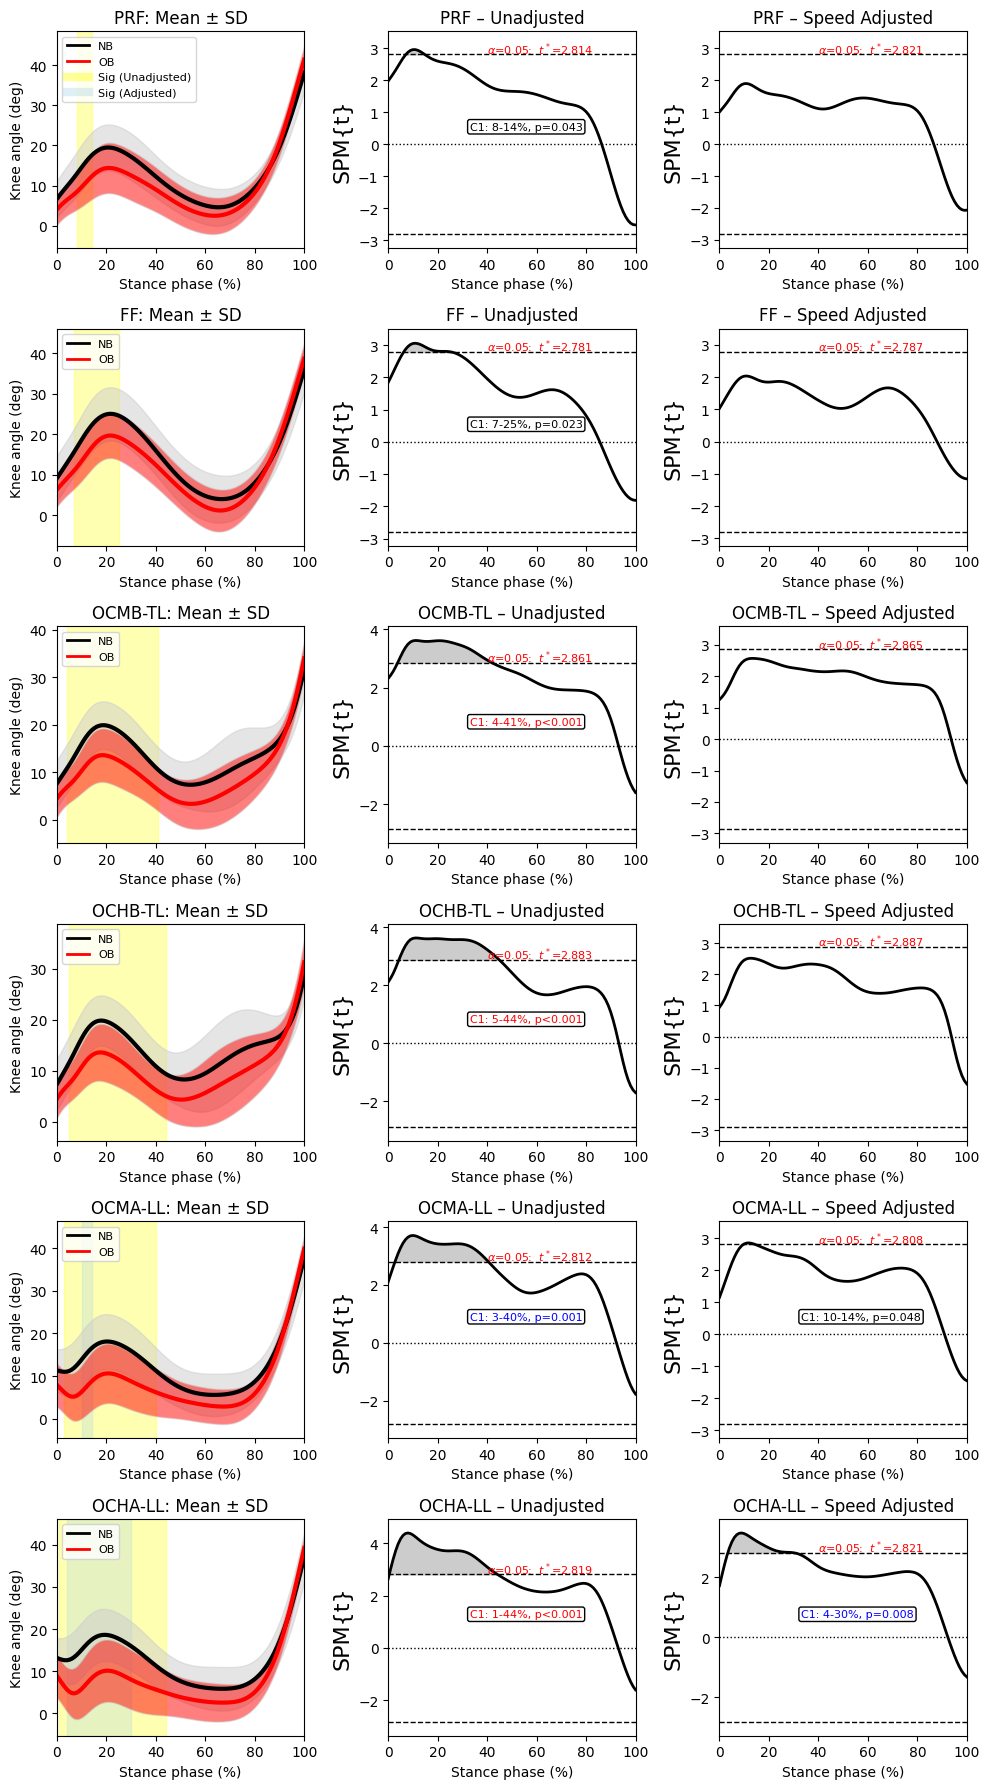

✅ Plot saved as 'Fig.2.png'


In [48]:
import numpy as np
import pandas as pd
import spm1d
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# -----------------------
# Config / inputs
# -----------------------
# Load speed info (CSV must have columns named by task codes like "PRF", "FF", etc.)
speed_df = pd.read_csv("speed_data_U.csv")

# Original task codes and display names
tasks = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]
task_display_names = {
    "PRF": "PRF",
    "FF": "FF",
    "OCMB": "OCMB-TL",
    "OCHB": "OCHB-TL",
    "OCMA": "OCMA-LL",
    "OCHA": "OCHA-LL"
}

# -----------------------
# Helpers
# -----------------------
def run_glm(nb_file, ob_file, task_name=None, alpha=0.05, two_tailed=True):
    """
    GLM with optional speed covariate adjustment when task_name is given and found in speed_df.
    Returns YA, YB, and the spm1d inference 'Fi'.
    """
    YA = pd.read_csv(nb_file, header=None).values  # Normal BMI
    YB = pd.read_csv(ob_file, header=None).values  # Obese
    Y = np.vstack((YA, YB))
    nA, nB = YA.shape[0], YB.shape[0]

    # Group regressor: 1 for group A (YA), 0 for group B (YB)
    x_group = np.concatenate((np.ones(nA), np.zeros(nB)))

    # Design matrix
    if task_name and (task_name in speed_df.columns):
        # Use as many speed rows as we have observations
        n_obs = nA + nB
        speeds_raw = speed_df[task_name].values
        if len(speeds_raw) < n_obs:
            raise ValueError(
                f"Not enough rows in speed_data_U.csv for task '{task_name}': need {n_obs}, found {len(speeds_raw)}"
            )
        speeds = speeds_raw[:n_obs]
        # Column order: intercept, group, speed
        X = np.column_stack((np.ones_like(x_group), x_group, speeds))
        c = [0, 1, 0]  # test group effect
    else:
        X = np.column_stack((np.ones_like(x_group), x_group))
        c = [0, 1]     # test group effect

    t = spm1d.stats.glm(Y, X, c)
    Fi = t.inference(alpha, two_tailed=two_tailed, interp=True)
    return YA, YB, Fi

def highlight_regions(ax, Fi, color='yellow', alpha=0.3):
    """Shade regions where the statistic exceeds the critical threshold."""
    tt = Fi.z
    thresh = Fi.zstar
    above = tt > thresh
    start = None
    for i, is_above in enumerate(above):
        if is_above and start is None:
            start = i
        elif (not is_above) and (start is not None):
            ax.axvspan(start, i - 1, color=color, alpha=alpha, zorder=0)
            start = None
    if start is not None:
        ax.axvspan(start, len(above) - 1, color=color, alpha=alpha, zorder=0)

def get_cluster_info(Fi):
    """
    Returns (bounds, pvals) where bounds is a list of (start_idx, end_idx).
    If Fi.clusters exists, extract from there; otherwise use Fi.z > Fi.zstar.
    pvals may be None if not available.
    """
    clusters = getattr(Fi, "clusters", None)
    pvals = getattr(Fi, "cluster_p_values", getattr(Fi, "p", None))
    if clusters is not None and len(clusters) > 0:
        bounds = []
        for c in clusters:
            s, e = _cluster_bounds_from_object(c)
            if (s is None) or (e is None):
                # Final fallback: reconstruct from Fi.z threshold if possible
                pass
            bounds.append((s, e))
        return bounds, pvals
    # Fallback: derive clusters from significance mask
    sig_mask = Fi.z > Fi.zstar
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    # No reliable per-cluster p-values in this case
    return bounds, None

def _cluster_bounds_from_object(cluster_obj):
    """
    Try multiple attribute names to extract integer index bounds from a spm1d cluster object.
    Returns (start_idx, end_idx) or (None, None) if not available.
    """
    # Try common attributes that store indices directly
    for attr in ('I', 'i', 'indices', 'inds', 'index'):
        if hasattr(cluster_obj, attr):
            arr = getattr(cluster_obj, attr)
            arr = np.asarray(arr)
            if arr.dtype == bool:
                inds = np.where(arr)[0]
            else:
                inds = arr.astype(int).ravel()
            if inds.size > 0:
                return int(inds[0]), int(inds[-1])
    # Try boolean masks
    for attr in ('mask', 'M'):
        if hasattr(cluster_obj, attr):
            mask = np.asarray(getattr(cluster_obj, attr)).astype(bool)
            inds = np.where(mask)[0]
            if inds.size > 0:
                return int(inds[0]), int(inds[-1])
    return None, None

def _cluster_bounds_from_sigmask(sig_mask):
    """
    Fallback: compute contiguous True runs from a boolean significance mask.
    Returns list of (start_idx, end_idx).
    """
    bounds = []
    start = None
    for i, v in enumerate(sig_mask):
        if v and start is None:
            start = i
        elif (not v) and (start is not None):
            bounds.append((start, i - 1))
            start = None
    if start is not None:
        bounds.append((start, len(sig_mask) - 1))
    return bounds

def annotate_significant_clusters(ax, Fi, x_rel=0.56, y_top_rel=0.56, line_spacing_rel=0.08):
    """Annotate each significant cluster with text in the upper-right of the SPM plot."""
    sig_mask = np.asarray(Fi.z > Fi.zstar, dtype=bool)
    if not np.any(sig_mask):
        return

    bounds, pvals = get_cluster_info(Fi)
    fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
    bounds = bounds if bounds else fallback_bounds
    alpha = getattr(Fi, "alpha", 0.05)

    if pvals is None:
        pvals_array = np.array([], dtype=float)
    else:
        try:
            pvals_array = np.atleast_1d(pvals).astype(float).ravel()
        except Exception:
            pvals_array = np.array([], dtype=float)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_text = xmin + x_rel * (xmax - xmin)
    y_start = ymin + y_top_rel * (ymax - ymin)
    dy = line_spacing_rel * (ymax - ymin)

    line_idx = 0
    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            if len(fallback_bounds) >= k:
                start_idx, end_idx = fallback_bounds[k - 1]
            else:
                continue

        p = None
        if len(pvals_array) >= k:
            p = float(pvals_array[k - 1])

        if (p is not None) and (p >= alpha):
            continue

        if p is None:
            text = f"C{k}: {start_idx}-{end_idx}%"
            color = 'purple'
        elif p < 0.001:
            text = f"C{k}: {start_idx}-{end_idx}%, p<0.001"
            color = 'red'
        elif p < 0.01:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'blue'
        else:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'black'

        y_text = y_start - line_idx * dy
        line_idx += 1
        ax.text(
            x_text, y_text, text,
            ha='left', va='center', fontsize=8, color=color,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2')
        )

def annotate_significant_clusters(ax, Fi, x_rel=0.62, y_top_rel=0.92, line_spacing_rel=0.08):
    """Annotate each significant cluster with text in the upper-right of the SPM plot."""
    sig_mask = np.asarray(Fi.z > Fi.zstar, dtype=bool)
    if not np.any(sig_mask):
        return

    bounds, pvals = get_cluster_info(Fi)
    fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
    bounds = bounds if bounds else fallback_bounds
    alpha = getattr(Fi, "alpha", 0.05)

    if pvals is None:
        pvals_array = np.array([], dtype=float)
    else:
        try:
            pvals_array = np.atleast_1d(pvals).astype(float).ravel()
        except Exception:
            pvals_array = np.array([], dtype=float)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_text = xmin + x_rel * (xmax - xmin)
    y_start = ymin + y_top_rel * (ymax - ymin)
    dy = line_spacing_rel * (ymax - ymin)

    line_idx = 0
    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            if len(fallback_bounds) >= k:
                start_idx, end_idx = fallback_bounds[k - 1]
            else:
                continue

        p = None
        if len(pvals_array) >= k:
            p = float(pvals_array[k - 1])

        if (p is not None) and (p >= alpha):
            continue

        if p is None:
            text = f"C{k}: {start_idx}-{end_idx}%"
            color = 'purple'
        elif p < 0.001:
            text = f"C{k}: {start_idx}-{end_idx}%, p<0.001"
            color = 'red'
        elif p < 0.01:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'blue'
        else:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'black'

        y_text = y_start - line_idx * dy
        line_idx += 1
        ax.text(
            x_text, y_text, text,
            ha='left', va='center', fontsize=8, color=color,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2')
        )

def print_inference_summary(YA, YB, Fi, task_label, tag):
    """
    Print mean difference over significant points and (if present) cluster p-values.
    Mean difference is YA - YB averaged across significant indices.
    """
    sig_mask = Fi.z > Fi.zstar
    if np.any(sig_mask):
        YA_sig = YA[:, sig_mask]
        YB_sig = YB[:, sig_mask]
        mean_diff = np.mean(YA_sig, axis=0) - np.mean(YB_sig, axis=0)
        overall_mean_diff = float(np.mean(mean_diff))
        print(f"{task_label} - {tag} – Mean Difference in Significant Region: {overall_mean_diff:.4f}")
        
        # Calculate Cohen's D for the significant region
        cohen_d = (np.mean(YA_sig) - np.mean(YB_sig)) / np.sqrt((np.std(YA_sig) ** 2 + np.std(YB_sig) ** 2) / 2)
        print(f"{task_label} - {tag} – Cohen's D in Significant Region: {cohen_d:.4f}")
    else:
        print(f"{task_label} - {tag} – No significant region found.")
        return  # nothing else to list

    # Cluster reporting
    bounds, pvals = get_cluster_info(Fi)
    alpha = getattr(Fi, "alpha", 0.05)

    if bounds:
        for k, (bnd) in enumerate(bounds, start=1):
            start_idx, end_idx = bnd
            p = None
            if pvals is not None and len(pvals) >= k:
                p = float(pvals[k-1])
            if start_idx is None or end_idx is None:
                fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
                if len(fallback_bounds) >= k:
                    start_idx, end_idx = fallback_bounds[k-1]
            if p is None:
                line = f"  - Cluster {k}: idx={start_idx}–{end_idx}"
            else:
                sigflag = "SIG" if (p < alpha) else "ns"
                line = f"  - Cluster {k}: p={p:.4f}, idx={start_idx}–{end_idx} [{sigflag}]"
            print(line)

def annotate_significant_clusters(ax, Fi, x_rel=0.33, y_top_rel=0.56, line_spacing_rel=0.08):
    """Annotate each significant cluster with text in the upper-right of the SPM plot."""
    sig_mask = np.asarray(Fi.z > Fi.zstar, dtype=bool)
    if not np.any(sig_mask):
        return

    bounds, pvals = get_cluster_info(Fi)
    fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
    bounds = bounds if bounds else fallback_bounds
    alpha = getattr(Fi, "alpha", 0.05)

    if pvals is None:
        pvals_array = np.array([], dtype=float)
    else:
        try:
            pvals_array = np.atleast_1d(pvals).astype(float).ravel()
        except Exception:
            pvals_array = np.array([], dtype=float)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_text = xmin + x_rel * (xmax - xmin)
    y_start = ymin + y_top_rel * (ymax - ymin)
    dy = line_spacing_rel * (ymax - ymin)

    line_idx = 0
    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            if len(fallback_bounds) >= k:
                start_idx, end_idx = fallback_bounds[k - 1]
            else:
                continue

        p = None
        if len(pvals_array) >= k:
            p = float(pvals_array[k - 1])

        if (p is not None) and (p >= alpha):
            continue

        if p is None:
            text = f"C{k}: {start_idx}-{end_idx}%"
            color = 'purple'
        elif p < 0.001:
            text = f"C{k}: {start_idx}-{end_idx}%, p<0.001"
            color = 'red'
        elif p < 0.01:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'blue'
        else:
            text = f"C{k}: {start_idx}-{end_idx}%, p={p:.3f}"
            color = 'black'

        y_text = y_start - line_idx * dy
        line_idx += 1
        ax.text(
            x_text, y_text, text,
            ha='left', va='center', fontsize=8, color=color,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2')
        )

# -----------------------
# Figure: 6 tasks × (Mean±SD | Unadj | Adj)
# -----------------------
fig, axs = plt.subplots(6, 3, figsize=(10, 18))

for i, task in enumerate(tasks):
    display_name = task_display_names[task]
    nb_file = f"NB_{task}.csv"
    ob_file = f"OB_{task}.csv"

    # Run GLMs
    YA, YB, ti_unadj = run_glm(nb_file, ob_file, task_name=None)
    _,  _,  ti_adj   = run_glm(nb_file, ob_file, task_name=task)

    # ======= PRINT TASK HEADER =======
    print(f"\n====== {display_name} ======")
    print_inference_summary(YA, YB, ti_unadj, display_name, "Speed unadjusted")
    print_inference_summary(YA, YB, ti_adj,   display_name, "Speed adjusted")

    # Column 1: Mean ± SD with shaded significant regions (unadj=yellow, adj=lightblue)
    ax_mean = axs[i, 0]
    highlight_regions(ax_mean, ti_unadj, color='yellow', alpha=0.3)
    highlight_regions(ax_mean, ti_adj, color='lightblue', alpha=0.3)
    spm1d.plot.plot_mean_sd(YA, ax=ax_mean)                          # Normal BMI (black)
    spm1d.plot.plot_mean_sd(YB, ax=ax_mean, linecolor='r', facecolor='r')  # Obese (red)
    ax_mean.set_title(f'{display_name}: Mean ± SD')
    ax_mean.set_xlabel('Stance phase (%)')
    ax_mean.set_ylabel('Knee angle (deg)')

    # Remove gridlines for column 1
    ax_mean.grid(False)

    # ✅ Legends
    if i == 0:
        # Full legend only on the first plot (1,1)
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color='black', lw=2, label='NB'),
                Line2D([0], [0], color='red', lw=2, label='OB'),
                Line2D([0], [0], color='yellow', lw=6, alpha=0.4, label='Sig (Unadjusted)'),
                Line2D([0], [0], color='lightblue', lw=6, alpha=0.4, label='Sig (Adjusted)'),
            ],
            loc='upper left', fontsize=8, frameon=True
        )
    elif i in [1, 2, 3, 4, 5]:  # Plots (2,1)–(6,1)
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color='black', lw=2, label='NB'),
                Line2D([0], [0], color='red', lw=2, label='OB')
            ],
            loc='upper left', fontsize=8, frameon=True
        )

    # Column 2: Unadjusted SPM
    ax_unadj = axs[i, 1]
    ti_unadj.plot(ax=ax_unadj)
    ti_unadj.plot_threshold_label(ax=ax_unadj, fontsize=8)
    annotate_significant_clusters(ax_unadj, ti_unadj)
    ax_unadj.set_title(f'{display_name} – Unadjusted')
    ax_unadj.set_xlabel('Stance phase (%)')

    # Remove gridlines for column 2
    ax_unadj.grid(False)

    # Column 3: Speed-Adjusted SPM
    ax_adj = axs[i, 2]
    ti_adj.plot(ax=ax_adj)
    ti_adj.plot_threshold_label(ax=ax_adj, fontsize=8)
    annotate_significant_clusters(ax_adj, ti_adj)
    ax_adj.set_title(f'{display_name} – Speed Adjusted')
    ax_adj.set_xlabel('Stance phase (%)')

    # Remove gridlines for column 3
    ax_adj.grid(False)

# Finalize figure
plt.tight_layout()
plt.savefig("Fig.2.png", dpi=1000)
plt.show()
print("✅ Plot saved as 'Fig.2.png'")


====== PRF ======
PRF - Speed unadjusted: cluster-wise Cohen's d (NB - OB)
  - Cluster 1: 48-59%, p=0.0165, mean difference=-0.1236, Cohen's d=-1.0252 [NB < OB]
  - Cluster 2: 72-83%, p=0.0162, mean difference=-0.1452, Cohen's d=-1.0239 [NB < OB]
PRF - Speed adjusted: cluster-wise Cohen's d (NB - OB)
  - Cluster 1: 82-89%, p=0.0277, mean difference=-0.1403, Cohen's d=-0.9330 [NB < OB]

====== FF ======
FF - Speed unadjusted: cluster-wise Cohen's d (NB - OB)
  - Cluster 1: 9-20%, p=0.0055, mean difference=0.2942, Cohen's d=1.3298 [NB > OB]
  - Cluster 2: 79-90%, p=0.0065, mean difference=-0.2114, Cohen's d=-1.2984 [NB < OB]
FF - Speed adjusted: cluster-wise Cohen's d (NB - OB)
  - Cluster 1: 11-16%, p=0.0302, mean difference=0.3131, Cohen's d=1.4292 [NB > OB]
  - Cluster 2: 82-91%, p=0.0134, mean difference=-0.2085, Cohen's d=-1.2872 [NB < OB]

====== OCMB-TL ======
OCMB-TL - Speed unadjusted: cluster-wise Cohen's d (NB - OB)
  - Cluster 1: 8-19%, p=0.0078, mean difference=0.2594, Cohe

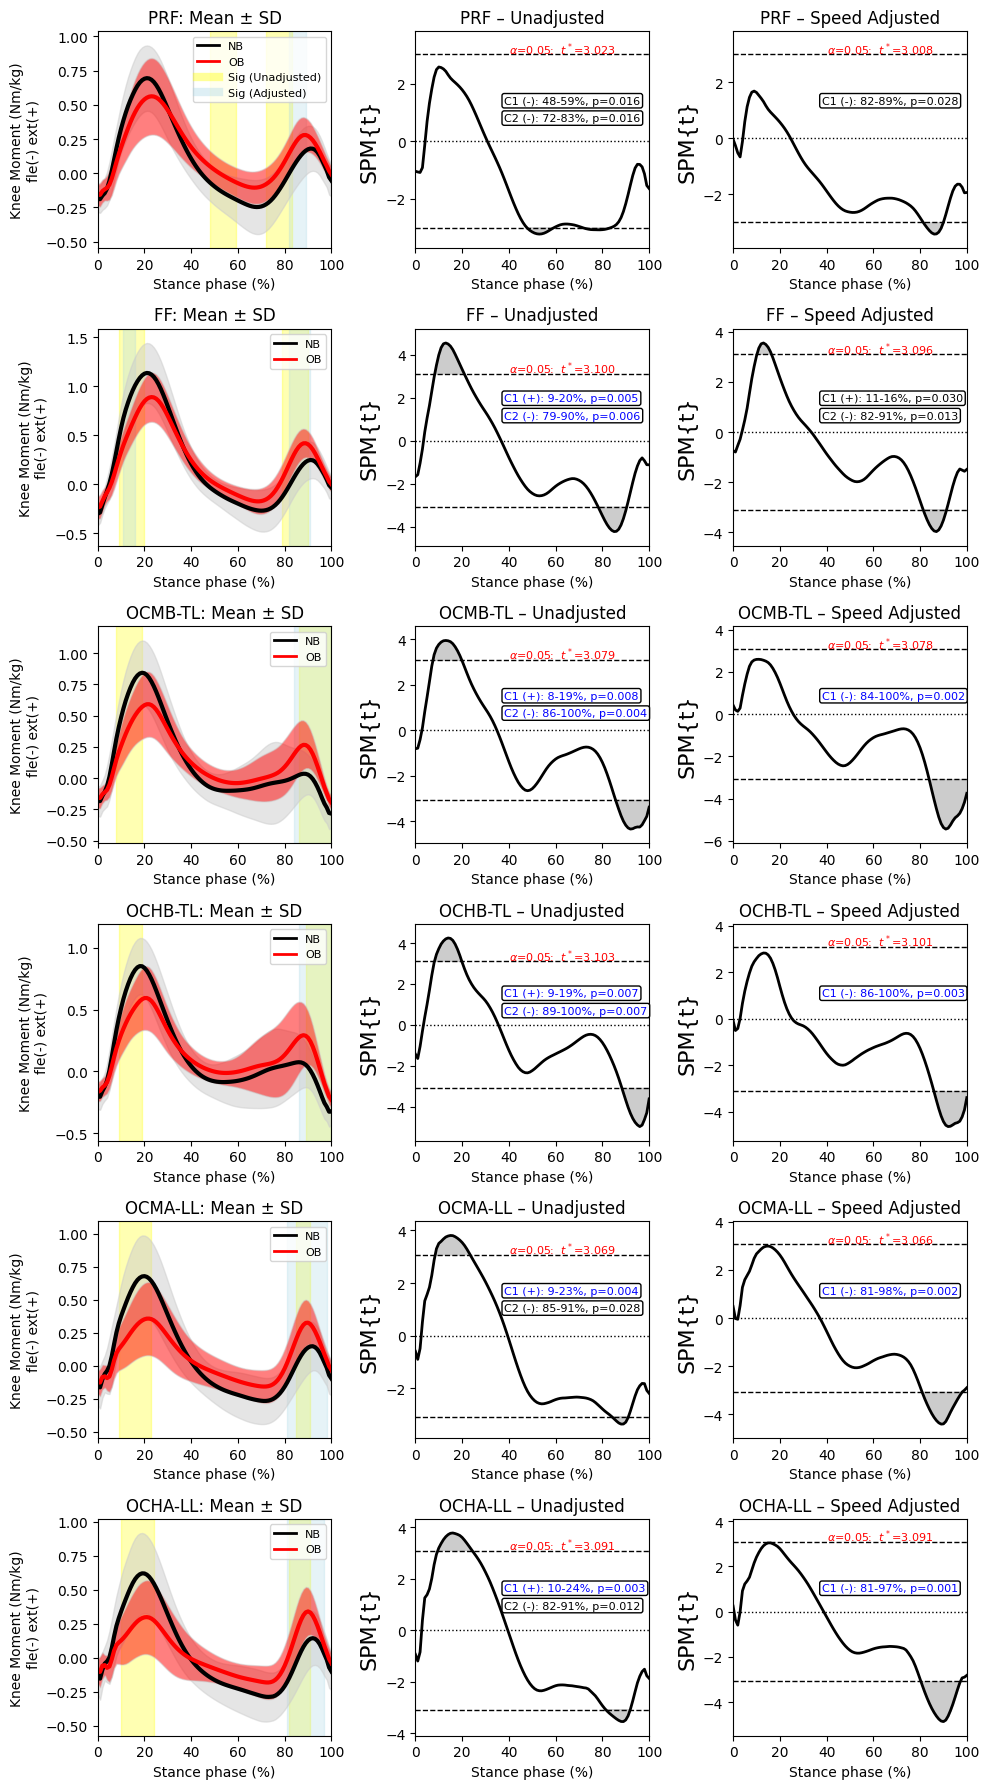

✅ Plot saved as 'Fig.3.png'


In [49]:
import numpy as np
import pandas as pd
import spm1d
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

# -----------------------
# Config / inputs
# -----------------------
speed_df = pd.read_csv("speed_data_U.csv")

tasks = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]
task_display_names = {
    "PRF": "PRF",
    "FF": "FF",
    "OCMB": "OCMB-TL",
    "OCHB": "OCHB-TL",
    "OCMA": "OCMA-LL",
    "OCHA": "OCHA-LL"
}

# -----------------------
# Helpers
# -----------------------
def run_glm(nb_file, ob_file, task_name=None, alpha=0.05, two_tailed=True):
    YA = pd.read_csv(nb_file, header=None).values
    YB = pd.read_csv(ob_file, header=None).values
    Y = np.vstack((YA, YB))
    nA, nB = YA.shape[0], YB.shape[0]

    x_group = np.concatenate((np.ones(nA), np.zeros(nB)))

    if task_name and (task_name in speed_df.columns):
        n_obs = nA + nB
        speeds_raw = speed_df[task_name].values
        if len(speeds_raw) < n_obs:
            raise ValueError(
                f"Not enough rows in speed_data_U.csv for task '{task_name}': need {n_obs}, found {len(speeds_raw)}"
            )
        speeds = speeds_raw[:n_obs]
        X = np.column_stack((np.ones_like(x_group), x_group, speeds))
        c = [0, 1, 0]
    else:
        X = np.column_stack((np.ones_like(x_group), x_group))
        c = [0, 1]

    t = spm1d.stats.glm(Y, X, c)
    Fi = t.inference(alpha, two_tailed=two_tailed, interp=True)
    return YA, YB, Fi

def _significant_mask(Fi):
    """Two-tailed"""
    z = np.asarray(Fi.z)
    thresh = float(Fi.zstar)
    return np.abs(z) > thresh

def highlight_regions(ax, Fi, color='yellow', alpha=0.3):
    """Shade significant regions for both positive and negative effects."""
    sig_mask = _significant_mask(Fi)
    start = None
    for i, is_sig in enumerate(sig_mask):
        if is_sig and start is None:
            start = i
        elif (not is_sig) and (start is not None):
            ax.axvspan(start, i - 1, color=color, alpha=alpha, zorder=0)
            start = None
    if start is not None:
        ax.axvspan(start, len(sig_mask) - 1, color=color, alpha=alpha, zorder=0)

def get_cluster_info(Fi):
    clusters = getattr(Fi, "clusters", None)
    pvals = getattr(Fi, "cluster_p_values", getattr(Fi, "p", None))
    if clusters is not None and len(clusters) > 0:
        bounds = []
        for c in clusters:
            s, e = _cluster_bounds_from_object(c)
            bounds.append((s, e))
        return bounds, pvals

    sig_mask = _significant_mask(Fi)
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    return bounds, None

def _cluster_bounds_from_object(cluster_obj):
    for attr in ("I", "i", "indices", "inds", "index"):
        if hasattr(cluster_obj, attr):
            arr = np.asarray(getattr(cluster_obj, attr))
            if arr.dtype == bool:
                inds = np.where(arr)[0]
            else:
                inds = arr.astype(int).ravel()
            if inds.size > 0:
                return int(inds[0]), int(inds[-1])

    for attr in ("mask", "M"):
        if hasattr(cluster_obj, attr):
            mask = np.asarray(getattr(cluster_obj, attr)).astype(bool)
            inds = np.where(mask)[0]
            if inds.size > 0:
                return int(inds[0]), int(inds[-1])

    return None, None

def _cluster_bounds_from_sigmask(sig_mask):
    bounds = []
    start = None
    for i, v in enumerate(sig_mask):
        if v and start is None:
            start = i
        elif (not v) and (start is not None):
            bounds.append((start, i - 1))
            start = None
    if start is not None:
        bounds.append((start, len(sig_mask) - 1))
    return bounds

def print_inference_summary(YA, YB, Fi, task_label, tag):
    sig_mask = _significant_mask(Fi)
    if np.any(sig_mask):
        YA_sig = YA[:, sig_mask]
        YB_sig = YB[:, sig_mask]
        mean_diff = np.mean(YA_sig, axis=0) - np.mean(YB_sig, axis=0)
        overall_mean_diff = float(np.mean(mean_diff))
        print(f"{task_label} - {tag} – Mean Difference in Significant Region: {overall_mean_diff:.4f}")

        cohen_d = (np.mean(YA_sig) - np.mean(YB_sig)) / np.sqrt(
            (np.std(YA_sig) ** 2 + np.std(YB_sig) ** 2) / 2
        )
        print(f"{task_label} - {tag} – Cohen's D in Significant Region: {cohen_d:.4f}")
    else:
        print(f"{task_label} - {tag} – No significant region found.")
        return

    bounds, pvals = get_cluster_info(Fi)
    alpha = getattr(Fi, "alpha", 0.05)

    if bounds:
        for k, (start_idx, end_idx) in enumerate(bounds, start=1):
            p = None
            if pvals is not None and len(pvals) >= k:
                p = float(pvals[k - 1])

            if start_idx is None or end_idx is None:
                fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
                if len(fallback_bounds) >= k:
                    start_idx, end_idx = fallback_bounds[k - 1]

            direction = np.mean(Fi.z[start_idx:end_idx + 1])
            sign_label = "positive" if direction >= 0 else "negative"

            if p is None:
                line = f"  - Cluster {k}: idx={start_idx}–{end_idx} [{sign_label}]"
            else:
                sigflag = "SIG" if (p < alpha) else "ns"
                line = f"  - Cluster {k}: p={p:.4f}, idx={start_idx}–{end_idx} [{sign_label}, {sigflag}]"
            print(line)

def _cohen_d_for_cluster(YA, YB, start_idx, end_idx):
    """Cohen's d from participant-level means within one cluster.

    Positive d means NB > OB; negative d means NB < OB.
    """
    a = np.mean(YA[:, start_idx:end_idx + 1], axis=1)
    b = np.mean(YB[:, start_idx:end_idx + 1], axis=1)
    n_a, n_b = len(a), len(b)
    mean_diff = float(np.mean(a) - np.mean(b))

    if n_a < 2 or n_b < 2:
        return np.nan, mean_diff

    pooled_var = (
        (n_a - 1) * np.var(a, ddof=1)
        + (n_b - 1) * np.var(b, ddof=1)
    ) / (n_a + n_b - 2)

    if pooled_var <= 0 or not np.isfinite(pooled_var):
        return np.nan, mean_diff
    return float(mean_diff / np.sqrt(pooled_var)), mean_diff


def print_clusterwise_cohen_d(YA, YB, Fi, task_label, tag):
    """Print mean difference and Cohen's d separately for every SPM cluster."""
    sig_mask = _significant_mask(Fi)
    bounds = _cluster_bounds_from_sigmask(sig_mask)
    if not bounds:
        print(f"{task_label} - {tag}: No significant region found.")
        return

    pvals = getattr(Fi, "cluster_p_values", getattr(Fi, "p", None))
    try:
        pvals = np.atleast_1d(pvals).astype(float).ravel() if pvals is not None else None
    except (TypeError, ValueError):
        pvals = None

    print(f"{task_label} - {tag}: cluster-wise Cohen's d (NB - OB)")
    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        d, mean_diff = _cohen_d_for_cluster(YA, YB, start_idx, end_idx)
        p = float(pvals[k - 1]) if pvals is not None and len(pvals) >= k else None
        p_text = "p=n/a" if p is None else ("p<0.001" if p < 0.001 else f"p={p:.4f}")
        d_text = "nan" if not np.isfinite(d) else f"{d:.4f}"
        direction = "NB > OB" if mean_diff >= 0 else "NB < OB"
        print(
            f"  - Cluster {k}: {start_idx}-{end_idx}%, {p_text}, "
            f"mean difference={mean_diff:.4f}, Cohen's d={d_text} [{direction}]"
        )


def annotate_significant_clusters(ax, Fi, x_rel=0.38, y_top_rel=0.68, line_spacing_rel=0.08):
    sig_mask = _significant_mask(Fi)
    if not np.any(sig_mask):
        return

    bounds, pvals = get_cluster_info(Fi)
    fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
    bounds = bounds if bounds else fallback_bounds
    alpha = getattr(Fi, "alpha", 0.05)

    if pvals is None:
        pvals_array = np.array([], dtype=float)
    else:
        try:
            pvals_array = np.atleast_1d(pvals).astype(float).ravel()
        except Exception:
            pvals_array = np.array([], dtype=float)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x_text = xmin + x_rel * (xmax - xmin)
    y_start = ymin + y_top_rel * (ymax - ymin)
    dy = line_spacing_rel * (ymax - ymin)

    line_idx = 0
    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            if len(fallback_bounds) >= k:
                start_idx, end_idx = fallback_bounds[k - 1]
            else:
                continue

        p = None
        if len(pvals_array) >= k:
            p = float(pvals_array[k - 1])

        if (p is not None) and (p >= alpha):
            continue

        direction = np.mean(Fi.z[start_idx:end_idx + 1])
        sign_text = "+" if direction >= 0 else "-"

        if p is None:
            text = f"C{k} ({sign_text}): {start_idx}-{end_idx}%"
            color = "purple" if direction >= 0 else "purple"
        elif p < 0.001:
            text = f"C{k} ({sign_text}): {start_idx}-{end_idx}%, p<0.001"
            color = "red" if direction >= 0 else "red"
        elif p < 0.01:
            text = f"C{k} ({sign_text}): {start_idx}-{end_idx}%, p={p:.3f}"
            color = "blue" if direction >= 0 else "blue"
        else:
            text = f"C{k} ({sign_text}): {start_idx}-{end_idx}%, p={p:.3f}"
            color = "black" if direction >= 0 else "black"

        y_text = y_start - line_idx * dy
        line_idx += 1
        ax.text(
            x_text, y_text, text,
            ha="left", va="center", fontsize=8, color=color,
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.2")
        )

# -----------------------
# Figure: 6 tasks × (Mean±SD | Unadj | Adj)
# -----------------------
fig, axs = plt.subplots(6, 3, figsize=(10, 18))

for i, task in enumerate(tasks):
    display_name = task_display_names[task]
    nb_file = f"NB_{task}_M.csv"
    ob_file = f"OB_{task}_M.csv"

    YA, YB, ti_unadj = run_glm(nb_file, ob_file, task_name=None)
    _, _, ti_adj = run_glm(nb_file, ob_file, task_name=task)

    print(f"\n====== {display_name} ======")
    print_clusterwise_cohen_d(YA, YB, ti_unadj, display_name, "Speed unadjusted")
    print_clusterwise_cohen_d(YA, YB, ti_adj, display_name, "Speed adjusted")

    ax_mean = axs[i, 0]
    highlight_regions(ax_mean, ti_unadj, color="yellow", alpha=0.3)
    highlight_regions(ax_mean, ti_adj, color="lightblue", alpha=0.3)
    spm1d.plot.plot_mean_sd(YA, ax=ax_mean)
    spm1d.plot.plot_mean_sd(YB, ax=ax_mean, linecolor="r", facecolor="r")
    ax_mean.set_title(f"{display_name}: Mean ± SD")
    ax_mean.set_xlabel("Stance phase (%)")
    ax_mean.set_ylabel("Knee Moment (Nm/kg)\nfle(-) ext(+)")
    ax_mean.grid(False)

    if i == 0:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color="black", lw=2, label="NB"),
                Line2D([0], [0], color="red", lw=2, label="OB"),
                Line2D([0], [0], color="yellow", lw=6, alpha=0.4, label="Sig (Unadjusted)"),
                Line2D([0], [0], color="lightblue", lw=6, alpha=0.4, label="Sig (Adjusted)"),
            ],
            loc="upper right", fontsize=8, frameon=True
        )
    else:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color="black", lw=2, label="NB"),
                Line2D([0], [0], color="red", lw=2, label="OB"),
            ],
            loc="upper right", fontsize=8, frameon=True
        )

    ax_unadj = axs[i, 1]
    ti_unadj.plot(ax=ax_unadj)
    ti_unadj.plot_threshold_label(ax=ax_unadj, fontsize=8)
    annotate_significant_clusters(ax_unadj, ti_unadj)
    ax_unadj.set_title(f"{display_name} – Unadjusted")
    ax_unadj.set_xlabel("Stance phase (%)")
    ax_unadj.grid(False)

    ax_adj = axs[i, 2]
    ti_adj.plot(ax=ax_adj)
    ti_adj.plot_threshold_label(ax=ax_adj, fontsize=8)
    annotate_significant_clusters(ax_adj, ti_adj)
    ax_adj.set_title(f"{display_name} – Speed Adjusted")
    ax_adj.set_xlabel("Stance phase (%)")
    ax_adj.grid(False)

plt.tight_layout()
plt.savefig("Fig.3.png", dpi=1000)
plt.show()
print("✅ Plot saved as 'Fig.3.png'")



====== PRF ======
PRF - ANOVA - Mean Differences in Significant Region:
  - Group 1 Mean: 14.56
  - Group 2 Mean: 11.86
  - Group 3 Mean: 9.91
  - Difference Group 1 - Group 2: 2.70
  - Difference Group 1 - Group 3: 4.65
  - Difference Group 2 - Group 3: 1.95
PRF - ANOVA - fNB vs Apple - Mean Difference in Significant Region: 2.7005
PRF - ANOVA - fNB vs Apple - Cohen's D in Significant Region: 0.3006
  - Cluster 1: p=0.0020, idx=2-35 [positive, SIG]
PRF - ANOVA - fNB vs Pear - Mean Difference in Significant Region: 4.6481
PRF - ANOVA - fNB vs Pear - Cohen's D in Significant Region: 0.5099
  - Cluster 1: p=0.0020, idx=2-35 [positive, SIG]
PRF - ANOVA - Apple vs Pear - Mean Difference in Significant Region: 1.9475
PRF - ANOVA - Apple vs Pear - Cohen's D in Significant Region: 0.2087
  - Cluster 1: p=0.0020, idx=2-35 [positive, SIG]
PRF - ANCOVA - No significant region found.
PRF - ANCOVA - fNB vs Apple - No significant region found.
PRF - ANCOVA - fNB vs Pear - No significant region fou

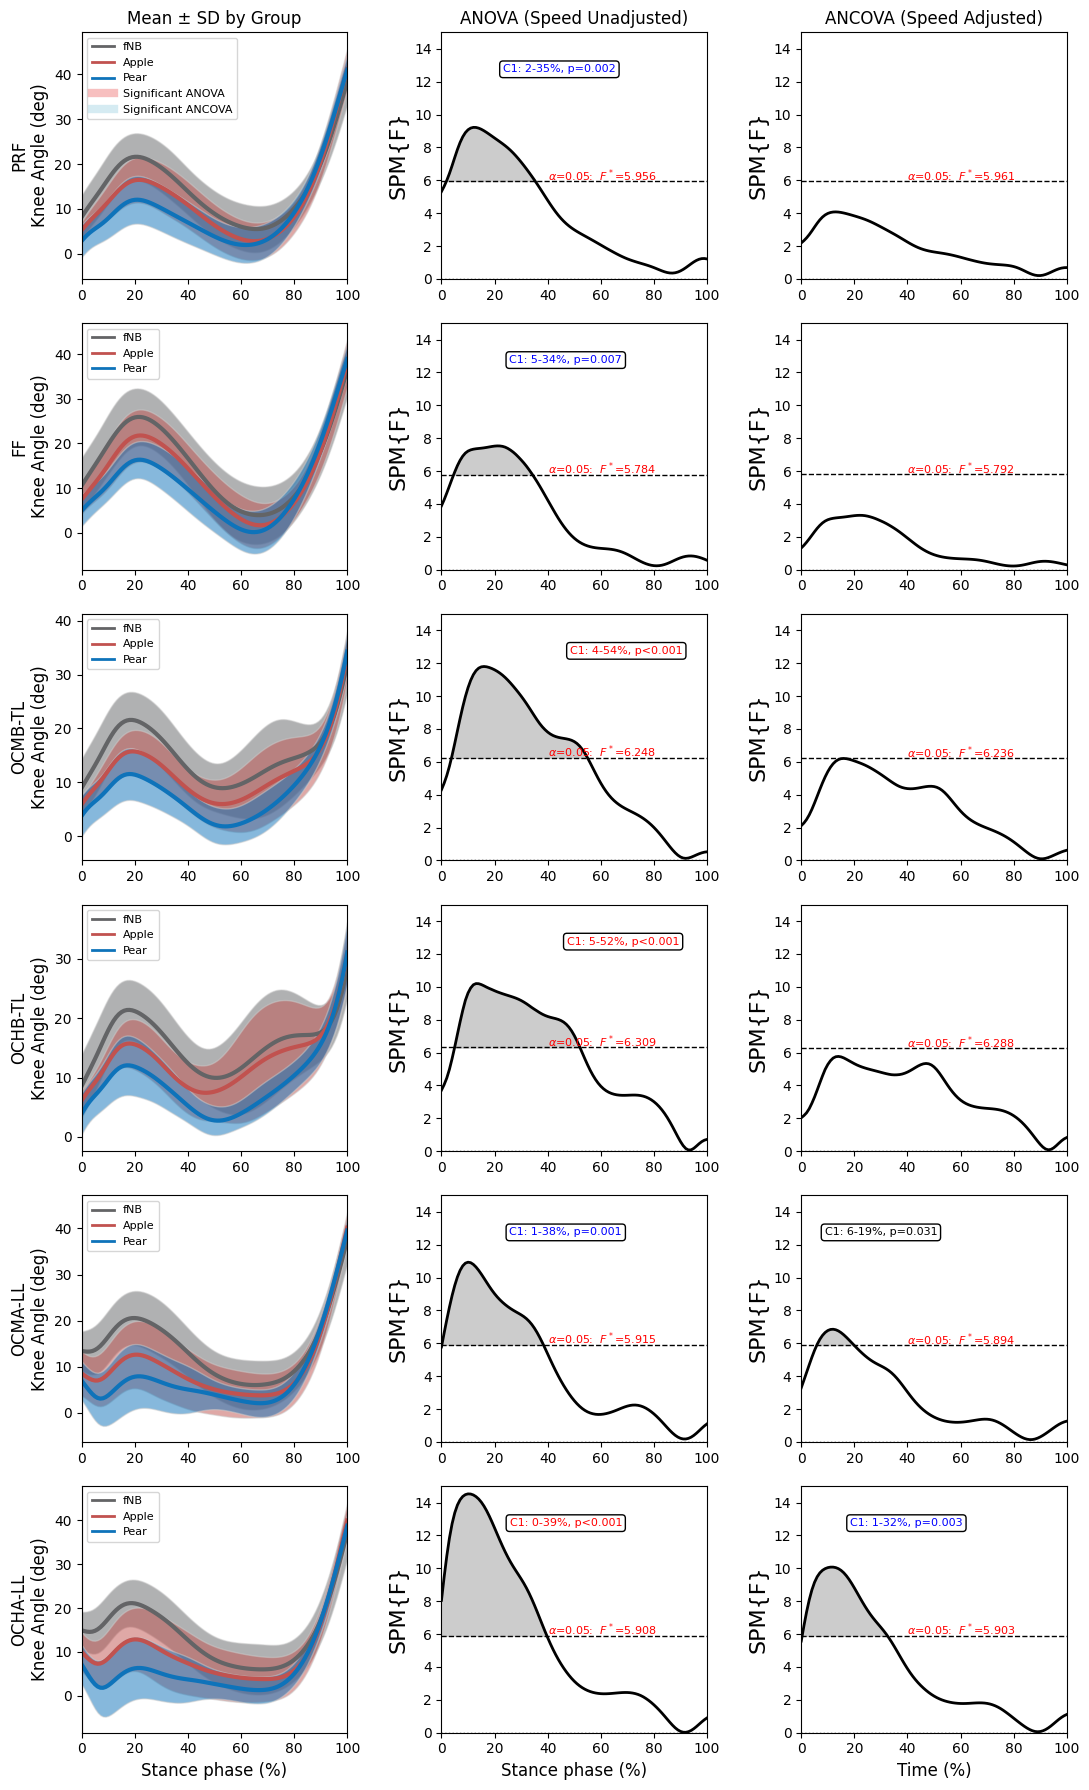

Saved: Fig.4.png


In [50]:
import pandas as pd
import numpy as np
from scipy import stats
import scipy.ndimage
import spm1d
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- File names and internal labels ---
datasets = [
    "Anova_PRF.csv", "Anova_FF.csv", "Anova_OCMB.csv",
    "Anova_OCHB.csv", "Anova_OCMA.csv", "Anova_OCHA.csv"
]
dataset_labels = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]

# --- Display names for plotting ---
display_names = {
    "PRF": "PRF",
    "FF": "FF",
    "OCMB": "OCMB-TL",
    "OCHB": "OCHB-TL",
    "OCMA": "OCMA-LL",
    "OCHA": "OCHA-LL"
}

# --- Plot colors and legend labels ---
colors = ['#636466', '#C1524F', '#0E73BA']
group_labels = ['fNB', 'Apple', 'Pear']

# --- Setup the 6x3 figure ---
fig, axs = plt.subplots(6, 3, figsize=(11, 18))


# ============================================================
# Helper functions
# ============================================================

def _significant_mask(Fi):
    """
    Return significant mask from an spm1d inference object.
    Prefer Fi.h0reject because it reflects cluster inference.
    """
    if hasattr(Fi, "h0reject"):
        return np.asarray(Fi.h0reject, dtype=bool)

    if hasattr(Fi, "z") and hasattr(Fi, "zstar"):
        return np.asarray(Fi.z > Fi.zstar, dtype=bool)

    return np.zeros_like(Fi.z, dtype=bool)


def _cluster_bounds_from_sigmask(sig_mask):
    """
    Convert a boolean significant mask into cluster bounds.
    Returns list of (start_idx, end_idx).
    """
    labels, n_clusters = scipy.ndimage.label(sig_mask)
    bounds = []

    for i in range(1, n_clusters + 1):
        idx = np.where(labels == i)[0]
        if len(idx) > 0:
            bounds.append((int(idx[0]), int(idx[-1])))

    return bounds


def get_cluster_info(Fi):
    """
    Extract cluster bounds and p-values from an spm1d inference object.
    """
    bounds = []
    pvals = []

    if hasattr(Fi, "clusters") and Fi.clusters is not None:
        for cluster in Fi.clusters:
            start_idx = None
            end_idx = None

            if hasattr(cluster, "endpoints"):
                endpoints = cluster.endpoints
                start_idx = int(np.floor(endpoints[0]))
                end_idx = int(np.ceil(endpoints[1]))

            elif hasattr(cluster, "indices"):
                indices = np.asarray(cluster.indices)
                if len(indices) > 0:
                    start_idx = int(indices[0])
                    end_idx = int(indices[-1])

            bounds.append((start_idx, end_idx))

            if hasattr(cluster, "p"):
                pvals.append(cluster.p)
            else:
                pvals.append(None)

    if not bounds:
        sig_mask = _significant_mask(Fi)
        bounds = _cluster_bounds_from_sigmask(sig_mask)
        pvals = [None] * len(bounds)

    return bounds, pvals


# ============================================================
# Print inference summary
# ============================================================

def print_inference_summary(YA, YB, Fi, task_label, tag):
    sig_mask = _significant_mask(Fi)

    if np.any(sig_mask):
        YA_sig = YA[:, sig_mask]
        YB_sig = YB[:, sig_mask]

        mean_diff = np.mean(YA_sig, axis=0) - np.mean(YB_sig, axis=0)
        overall_mean_diff = float(np.mean(mean_diff))

        print(
            f"{task_label} - {tag} - "
            f"Mean Difference in Significant Region: {overall_mean_diff:.4f}"
        )

        pooled_sd = np.sqrt(
            (np.std(YA_sig, ddof=1) ** 2 + np.std(YB_sig, ddof=1) ** 2) / 2
        )

        if pooled_sd == 0:
            cohen_d = np.nan
        else:
            cohen_d = (np.mean(YA_sig) - np.mean(YB_sig)) / pooled_sd

        print(
            f"{task_label} - {tag} - "
            f"Cohen's D in Significant Region: {cohen_d:.4f}"
        )

    else:
        print(f"{task_label} - {tag} - No significant region found.")
        return

    bounds, pvals = get_cluster_info(Fi)
    alpha = getattr(Fi, "alpha", 0.05)

    if bounds:
        for k, (start_idx, end_idx) in enumerate(bounds, start=1):
            p = None

            if pvals is not None and len(pvals) >= k:
                if pvals[k - 1] is not None:
                    p = float(pvals[k - 1])

            if start_idx is None or end_idx is None:
                fallback_bounds = _cluster_bounds_from_sigmask(sig_mask)
                if len(fallback_bounds) >= k:
                    start_idx, end_idx = fallback_bounds[k - 1]

            cluster_diff = (
                np.mean(YA[:, start_idx:end_idx + 1])
                - np.mean(YB[:, start_idx:end_idx + 1])
            )
            sign_label = "positive" if cluster_diff >= 0 else "negative"

            if p is None:
                line = f"  - Cluster {k}: idx={start_idx}-{end_idx} [{sign_label}]"
            else:
                sigflag = "SIG" if (p < alpha) else "ns"
                line = (
                    f"  - Cluster {k}: p={p:.4f}, "
                    f"idx={start_idx}-{end_idx} [{sign_label}, {sigflag}]"
                )

            print(line)


# ============================================================
# Plot annotation functions
# ============================================================

def annotate_p_values(ax, Fi):
    bounds, pvals = get_cluster_info(Fi)
    alpha = getattr(Fi, "alpha", 0.05)

    if not bounds:
        return

    ymin, ymax = ax.get_ylim()
    y_text = ymax * 0.85

    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            continue

        p_val = None
        if pvals is not None and len(pvals) >= k:
            p_val = pvals[k - 1]

        if p_val is None or p_val >= alpha:
            continue

        x_center = (start_idx + end_idx)*1.2

        if p_val < 0.001:
            color = 'red'
            text = f"C{k}: {start_idx}-{end_idx}%, p<0.001"
        elif p_val < 0.01:
            color = 'blue'
            text = f"C{k}: {start_idx}-{end_idx}%, p={p_val:.3f}"
        else:
            color = 'black'
            text = f"C{k}: {start_idx}-{end_idx}%, p={p_val:.3f}"

        ax.text(
            x_center, y_text, text,
            ha='center', va='center',
            fontsize=8,
            color=color,
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                boxstyle='round,pad=0.3'
            )
        )


def highlight_significant_regions(ax, Fi, color='yellow', alpha=0.3):
    sig_mask = _significant_mask(Fi)
    bounds = _cluster_bounds_from_sigmask(sig_mask)

    for start_idx, end_idx in bounds:
        ax.axvspan(
            start_idx, end_idx,
            color=color,
            alpha=alpha,
            zorder=0
        )


def annotate_significant_regions_on_mean_plot(ax, Fi, label, color):
    bounds, pvals = get_cluster_info(Fi)
    alpha = getattr(Fi, "alpha", 0.05)

    if not bounds:
        return

    ymin, ymax = ax.get_ylim()
    y_text = ymin + (ymax - ymin) * 0.92

    for k, (start_idx, end_idx) in enumerate(bounds, start=1):
        if start_idx is None or end_idx is None:
            continue

        p_val = None
        if pvals is not None and len(pvals) >= k:
            p_val = pvals[k - 1]

        if p_val is None or p_val >= alpha:
            continue

        x_center = (start_idx + end_idx) / 2

        if p_val < 0.001:
            p_text = "p<0.001"
        else:
            p_text = f"p={p_val:.3f}"

       


def compute_mean_differences(Y, A, Fi, label):
    sig_mask = _significant_mask(Fi)

    if not np.any(sig_mask):
        print(f"{label} - No significant region found.")
        return

    Y_sig = Y[:, sig_mask]
    unique_groups = np.unique(A)

    print(f"{label} - Mean Differences in Significant Region:")

    group_means = {}

    for g in unique_groups:
        group_data = Y_sig[np.asarray(A) == g]
        group_mean = group_data.mean()
        group_means[g] = group_mean
        print(f"  - Group {g} Mean: {group_mean:.2f}")

    for i in range(len(unique_groups)):
        for j in range(i + 1, len(unique_groups)):
            gi = unique_groups[i]
            gj = unique_groups[j]
            diff = group_means[gi] - group_means[gj]
            print(f"  - Difference Group {gi} - Group {gj}: {diff:.2f}")


def print_pairwise_inference_summaries(Y, A, Fi, label):
    unique_groups = np.unique(A)

    for i in range(len(unique_groups)):
        for j in range(i + 1, len(unique_groups)):
            gi = unique_groups[i]
            gj = unique_groups[j]

            YA = Y[np.asarray(A) == gi]
            YB = Y[np.asarray(A) == gj]

            tag = f"{group_labels[int(gi) - 1]} vs {group_labels[int(gj) - 1]}"
            print_inference_summary(YA, YB, Fi, label, tag)


# ============================================================
# Main loop
# ============================================================

for row_idx, (file, label) in enumerate(zip(datasets, dataset_labels)):
    display_label = display_names[label]

    df = pd.read_csv(file)

    Y = df.drop(columns=["Group", "Speed"]).values
    A = df["Group"].values
    speed = df["Speed"].values

    n_timepoints = Y.shape[1]

    # Speed adjustment
    Y_speed_adjusted = np.empty_like(Y)

    for i in range(n_timepoints):
        slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
        Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

    # Run ANOVA and ANCOVA
    Fi_anova = spm1d.stats.anova1(
        Y, A, equal_var=True
    ).inference(alpha=0.05, interp=False)

    Fi_ancova = spm1d.stats.anova1(
        Y_speed_adjusted, A, equal_var=True
    ).inference(alpha=0.05, interp=False)

    # --------------------------------------------------------
    # Column 1: Mean ± SD with significant-region highlights
    # --------------------------------------------------------
    ax_mean = axs[row_idx, 0]

    highlight_significant_regions(
        ax_mean, Fi_anova,
        color='lightcoral',
        alpha=0.3
    )

    highlight_significant_regions(
        ax_mean, Fi_ancova,
        color='lightblue',
        alpha=0.3
    )

    for i, group in enumerate(np.unique(A)):
        group_data = Y[np.asarray(A) == group]
        spm1d.plot.plot_mean_sd(
            group_data,
            ax=ax_mean,
            linecolor=colors[i],
            facecolor=colors[i]
        )

    if row_idx == 0:
        ax_mean.set_title('Mean ± SD by Group', fontsize=12)

    if row_idx == 5:
        ax_mean.set_xlabel('Stance phase (%)', fontsize=12)

    ax_mean.set_ylabel(f'{display_label}\nKnee Angle (deg)', fontsize=12)
    ax_mean.grid(False)

    annotate_significant_regions_on_mean_plot(
        ax_mean, Fi_anova,
        label='ANOVA',
        color='lightcoral'
    )

    annotate_significant_regions_on_mean_plot(
        ax_mean, Fi_ancova,
        label='ANCOVA',
        color='lightblue'
    )

    if row_idx == 0:
        full_legend = [
            *[
                Line2D([0], [0], color=colors[i], lw=2, label=group_labels[i])
                for i in range(len(group_labels))
            ],
            Line2D(
                [0], [0],
                color='lightcoral',
                lw=6,
                alpha=0.5,
                label='Significant ANOVA'
            ),
            Line2D(
                [0], [0],
                color='lightblue',
                lw=6,
                alpha=0.5,
                label='Significant ANCOVA'
            )
        ]
        ax_mean.legend(handles=full_legend, loc='upper left', fontsize=8, frameon=True)

    else:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color=colors[i], lw=2, label=group_labels[i])
                for i in range(len(group_labels))
            ],
            loc='upper left',
            fontsize=8,
            frameon=True
        )

    # --------------------------------------------------------
    # Column 2: ANOVA plot
    # --------------------------------------------------------
    ax_anova = axs[row_idx, 1]

    Fi_anova.plot(ax=ax_anova)
    Fi_anova.plot_threshold_label(ax=ax_anova, fontsize=8)

    if row_idx == 0:
        ax_anova.set_title('ANOVA (Speed Unadjusted)', fontsize=12)

    if row_idx == 5:
        ax_anova.set_xlabel('Stance phase (%)', fontsize=12)

    ax_anova.set_ylim(0, 15)
    annotate_p_values(ax_anova, Fi_anova)

    # --------------------------------------------------------
    # Column 3: ANCOVA plot
    # --------------------------------------------------------
    ax_ancova = axs[row_idx, 2]

    Fi_ancova.plot(ax=ax_ancova)
    Fi_ancova.plot_threshold_label(ax=ax_ancova, fontsize=8)

    if row_idx == 0:
        ax_ancova.set_title('ANCOVA (Speed Adjusted)', fontsize=12)

    if row_idx == 5:
        ax_ancova.set_xlabel('Time (%)', fontsize=12)

    ax_ancova.set_ylim(0, 15)
    annotate_p_values(ax_ancova, Fi_ancova)

    # --------------------------------------------------------
    # Print summaries
    # --------------------------------------------------------
    print(f"\n====== {display_label} ======")

    compute_mean_differences(
        Y, A, Fi_anova,
        f"{display_label} - ANOVA"
    )

    print_pairwise_inference_summaries(
        Y, A, Fi_anova,
        f"{display_label} - ANOVA"
    )

    compute_mean_differences(
        Y_speed_adjusted, A, Fi_ancova,
        f"{display_label} - ANCOVA"
    )

    print_pairwise_inference_summaries(
        Y_speed_adjusted, A, Fi_ancova,
        f"{display_label} - ANCOVA"
    )


# ============================================================
# Save and show
# ============================================================

plt.tight_layout()
plt.savefig(
    'Fig.4.png',
    dpi=1000
)
plt.show()

print("Saved: Fig.4.png")



====== PRF ======
PRF - ANOVA - No significant region found.
PRF - ANCOVA - No significant region found.

====== FF ======
FF - ANOVA - Cluster-wise Cohen's d:
  Cluster 1: 12-16%, p=0.0288
    fNB: mean=0.9456, n=10
    Apple: mean=0.6026, n=10
    Pear: mean=0.5640, n=10
    Cohen's d (fNB - Apple) = 1.2925
    Cohen's d (fNB - Pear) = 1.5639
    Cohen's d (Apple - Pear) = 0.1999
  Cluster 2: 85-86%, p=0.0481
    fNB: mean=0.1056, n=10
    Apple: mean=0.4091, n=10
    Pear: mean=0.3329, n=10
    Cohen's d (fNB - Apple) = -1.6503
    Cohen's d (fNB - Pear) = -1.1264
    Cohen's d (Apple - Pear) = 0.4374
FF - ANCOVA - No significant region found.

====== OCMB-TL ======
OCMB-TL - ANOVA - Cluster-wise Cohen's d:
  Cluster 1: 89-100%, p=0.0062
    fNB: mean=-0.1366, n=10
    Apple: mean=0.0774, n=10
    Pear: mean=0.0655, n=10
    Cohen's d (fNB - Apple) = -1.5596
    Cohen's d (fNB - Pear) = -1.7926
    Cohen's d (Apple - Pear) = 0.1084
OCMB-TL - ANCOVA - Cluster-wise Cohen's d:
  Clust

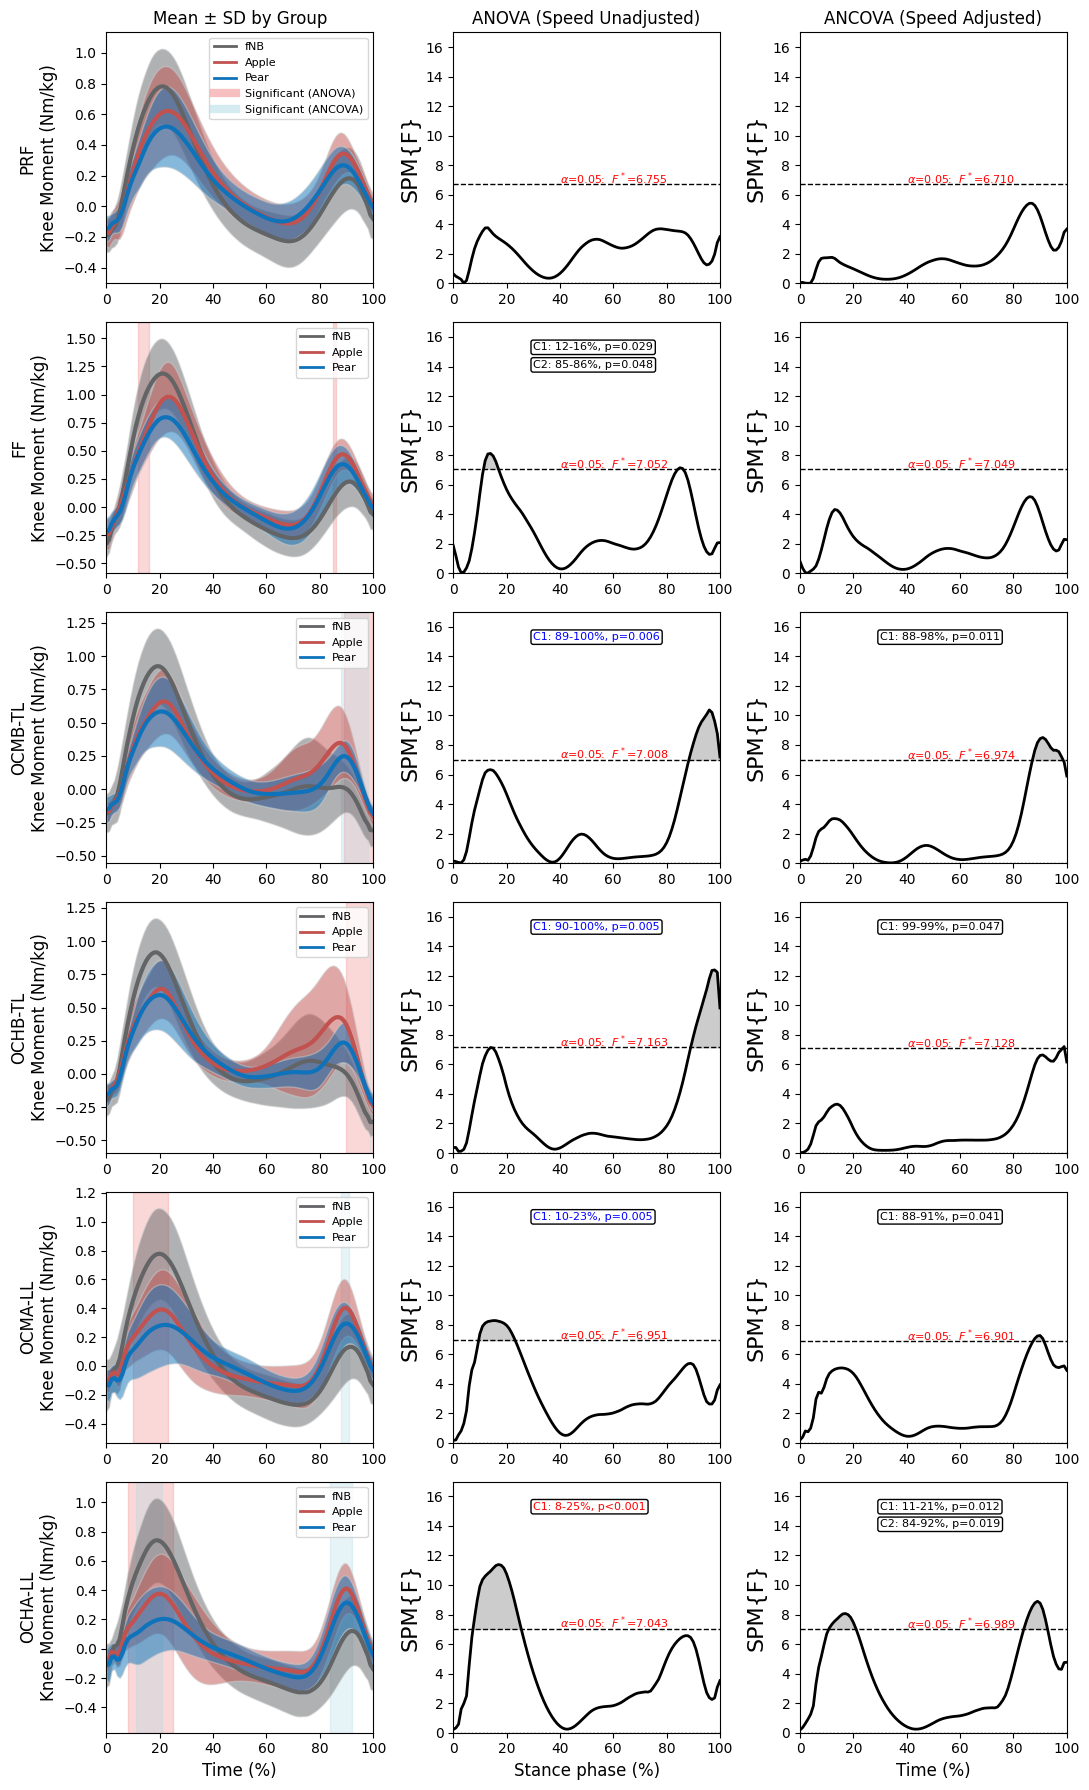

✅ Saved: Fig.5.png


In [51]:
import pandas as pd
import numpy as np
from scipy import stats
import scipy.ndimage
import spm1d
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import inspect

# ---------------------------------------------------
# 0. spm1d traceMV 
# ---------------------------------------------------
try:
    reml_mod = spm1d.stats._reml
    sig = inspect.signature(reml_mod.traceMV)
    if len(sig.parameters) == 2:
        _orig_traceMV = reml_mod.traceMV

        def _traceMV_patch(V, X, c=None):
            return _orig_traceMV(V, X)

        reml_mod.traceMV = _traceMV_patch
        print("✅ Patched spm1d.stats._reml.traceMV to accept 3 args (runtime shim).")
except Exception as e:
    print("spm1d traceMV patch skipped / failed:", e)


# ---------------------------------------------------
# 1. Files and labels
# ---------------------------------------------------
datasets = [
    "Anova_PRF_M.csv", "Anova_FF_M.csv", "Anova_OCMB_M.csv",
    "Anova_OCHB_M.csv", "Anova_OCMA_M.csv", "Anova_OCHA_M.csv"
]
dataset_labels = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]

display_names = {
    "PRF":  "PRF",
    "FF":   "FF",
    "OCMB": "OCMB-TL",
    "OCHB": "OCHB-TL",
    "OCMA": "OCMA-LL",
    "OCHA": "OCHA-LL",
}

colors = ['#636466', '#C1524F', '#0E73BA']
group_labels = ['fNB', 'Apple', 'Pear']


# ---------------------------------------------------
# 2. Highlight significant regions function (Mean plot)
# ---------------------------------------------------
def highlight_significant_regions(ax, Fi, color='yellow', alpha=0.3):
    """
    Highlight significant regions on a mean plot based on the SPM inference result Fi.
    """
    tt = Fi.z
    thresh = Fi.zstar
    above_thresh = tt > thresh

    start = None
    for i, val in enumerate(above_thresh):
        if val and start is None:
            start = i
        elif (not val) and (start is not None):
            ax.axvspan(start, i - 1, color=color, alpha=alpha, zorder=0)
            start = None

    if start is not None:
        ax.axvspan(start, len(above_thresh) - 1, color=color, alpha=alpha, zorder=0)


# ---------------------------------------------------
# 3. p-value + significant region range text function
# ---------------------------------------------------
def annotate_p_values(ax, Fi,
                      x_rel=0.60,
                      y_top_rel=0.90,
                      line_spacing_rel=0.07):
    """
    Display p-value and significant region range for each significant cluster from SPM result Fi.
    Example: C1: 25-42%, p=0.012
    """
    sig_mask = np.asarray(Fi.z > Fi.zstar, dtype=bool)

    if not np.any(sig_mask):
        return

    labels, n_clusters = scipy.ndimage.label(sig_mask)

    if n_clusters == 0:
        return

    spm_clusters = list(getattr(Fi, "clusters", []))
    n_spm_clusters = len(spm_clusters)
    n_use = min(n_clusters, n_spm_clusters)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_text = (xmin + x_rel * (xmax - xmin))/2
    y_start = ymin + y_top_rel * (ymax - ymin)
    dy = line_spacing_rel * (ymax - ymin)

    line_idx = 0

    for k in range(1, n_use + 1):
        idx = np.where(labels == k)[0]

        if idx.size == 0:
            continue

        start_idx = int(idx[0])
        end_idx = int(idx[-1])

        clust = spm_clusters[k - 1]
        p_val = getattr(clust, "p", getattr(clust, "P", None))

        if p_val is None:
            text = f"C{k}: idx {start_idx}-{end_idx}%"
            color = "black"

        else:
            if p_val < 0.001:
                color = 'red'
                text = f"C{k}: {start_idx}-{end_idx}%, p<0.001"
            elif p_val < 0.01:
                color = 'blue'
                text = f"C{k}: {start_idx}-{end_idx}%, p={p_val:.3f}"
            elif p_val < 0.05:
                color = 'black'
                text = f"C{k}: {start_idx}-{end_idx}%, p={p_val:.3f}"
            else:
                continue

        y_text = y_start - line_idx * dy
        line_idx += 1

        ax.text(
            x_text, y_text, text,
            ha='left',
            va='center',
            fontsize=8,
            color=color,
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                boxstyle='round,pad=0.2'
            )
        )


# ---------------------------------------------------
# 4. significant cluster-wise Cohen's d calculation
# ---------------------------------------------------
def _independent_cohen_d(x1, x2):
    """Independent-groups Cohen's d using the pooled sample SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if pooled_var <= 0 or not np.isfinite(pooled_var):
        return np.nan
    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def compute_clusterwise_cohen_d(Y, A, Fi, label):
    """Print group means and pairwise Cohen's d for each significant cluster.

    Y can be the original or speed-adjusted data. Each participant is reduced
    to one mean value per cluster before Cohen's d is calculated.
    """
    sig_mask = np.asarray(Fi.z > Fi.zstar, dtype=bool)
    labels, n_clusters = scipy.ndimage.label(sig_mask)

    if n_clusters == 0:
        print(f"{label} - No significant region found.")
        return

    unique_groups = np.unique(A)
    spm_clusters = list(getattr(Fi, "clusters", []))
    print(f"{label} - Cluster-wise Cohen's d:")

    for cluster_no in range(1, n_clusters + 1):
        idx = np.where(labels == cluster_no)[0]
        if idx.size == 0:
            continue

        start_idx, end_idx = int(idx[0]), int(idx[-1])
        p_val = None
        if cluster_no <= len(spm_clusters):
            cluster = spm_clusters[cluster_no - 1]
            p_val = getattr(cluster, "p", getattr(cluster, "P", None))

        p_text = "p=n/a" if p_val is None else (
            "p<0.001" if p_val < 0.001 else f"p={p_val:.4f}"
        )
        print(f"  Cluster {cluster_no}: {start_idx}-{end_idx}%, {p_text}")

        # One value per participant: mean response across this cluster.
        subject_cluster_means = np.mean(Y[:, idx], axis=1)
        cluster_group_data = {}
        for group_index, group in enumerate(unique_groups):
            values = subject_cluster_means[A == group]
            cluster_group_data[group] = values
            name = group_labels[group_index] if group_index < len(group_labels) else f"Group {group}"
            print(f"    {name}: mean={np.mean(values):.4f}, n={len(values)}")

        for i in range(len(unique_groups)):
            for j in range(i + 1, len(unique_groups)):
                group1, group2 = unique_groups[i], unique_groups[j]
                name1 = group_labels[i] if i < len(group_labels) else f"Group {group1}"
                name2 = group_labels[j] if j < len(group_labels) else f"Group {group2}"
                d = _independent_cohen_d(
                    cluster_group_data[group1], cluster_group_data[group2]
                )
                d_text = "nan" if not np.isfinite(d) else f"{d:.4f}"
                print(f"    Cohen's d ({name1} - {name2}) = {d_text}")


def compute_mean_differences(Y, A, Fi, label):
    """
    
    Output the mean for each group and the differences between groups.
    """
    sig_mask = Fi.z > Fi.zstar

    if not np.any(sig_mask):
        print(f"{label} – No significant region found.")
        return

    Y_sig = Y[:, sig_mask]
    unique_groups = np.unique(A)

    print(f"{label} – Mean Differences in Significant Region:")

    group_means = {}

    for g in unique_groups:
        group_data = Y_sig[np.array(A) == g]
        group_mean = group_data.mean()
        group_means[g] = group_mean
        print(f"  ▸ Group {g} Mean: {group_mean:.2f}")

    for i in range(len(unique_groups)):
        for j in range(i + 1, len(unique_groups)):
            diff = group_means[unique_groups[i]] - group_means[unique_groups[j]]
            print(
                f"  ▸ Difference "
                f"(Group {unique_groups[i]} - Group {unique_groups[j]}): {diff:.2f}"
            )


# ---------------------------------------------------
# 5. 6x3 Figure
# ---------------------------------------------------
fig, axs = plt.subplots(6, 3, figsize=(11, 18))

for row_idx, (file, label) in enumerate(zip(datasets, dataset_labels)):
    display_label = display_names[label]

    df = pd.read_csv(file)

    Y = df.drop(columns=["Group", "Speed"]).values
    A = df["Group"].values
    speed = df["Speed"].values

    n_timepoints = Y.shape[1]

    # 속도 보정
    Y_speed_adjusted = np.empty_like(Y)

    for t in range(n_timepoints):
        slope, intercept, _, _, _ = stats.linregress(speed, Y[:, t])
        Y_speed_adjusted[:, t] = Y[:, t] - (slope * speed + intercept)

    # ANOVA & ANCOVA
    Fi_anova = spm1d.stats.anova1(
        Y, A, equal_var=True
    ).inference(alpha=0.05, interp=False)

    Fi_ancova = spm1d.stats.anova1(
        Y_speed_adjusted, A, equal_var=True
    ).inference(alpha=0.05, interp=False)

    # ---------------------------
    # 1 row: Mean ± SD + Significant Region Highlight
    # ---------------------------
    ax_mean = axs[row_idx, 0]

    highlight_significant_regions(ax_mean, Fi_anova, color='lightcoral', alpha=0.3)
    highlight_significant_regions(ax_mean, Fi_ancova, color='lightblue', alpha=0.3)

    unique_groups = np.unique(A)

    for i, g in enumerate(unique_groups):
        group_data = Y[A == g]
        spm1d.plot.plot_mean_sd(
            group_data,
            ax=ax_mean,
            linecolor=colors[i],
            facecolor=colors[i]
        )

    if row_idx == 0:
        ax_mean.set_title('Mean ± SD by Group', fontsize=12)

    if row_idx == len(datasets) - 1:
        ax_mean.set_xlabel('Time (%)', fontsize=12)

    ax_mean.set_ylabel(f'{display_label}\nKnee Moment (Nm/kg)', fontsize=12)
    ax_mean.grid(False)

    if row_idx == 0:
        full_legend = [
            *[
                Line2D([0], [0], color=colors[i], lw=2, label=group_labels[i])
                for i in range(len(unique_groups))
            ],
            Line2D([0], [0], color='lightcoral', lw=6, alpha=0.5, label='Significant (ANOVA)'),
            Line2D([0], [0], color='lightblue', lw=6, alpha=0.5, label='Significant (ANCOVA)'),
        ]

        ax_mean.legend(
            handles=full_legend,
            loc='upper right',
            fontsize=8,
            frameon=True
        )
    else:
        ax_mean.legend(
            handles=[
                Line2D([0], [0], color=colors[i], lw=2, label=group_labels[i])
                for i in range(len(unique_groups))
            ],
            loc='upper right',
            fontsize=8,
            frameon=True
        )

    # ---------------------------
    # 2 row: ANOVA SPM{F} plot
    # ---------------------------
    ax_anova = axs[row_idx, 1]

    Fi_anova.plot(ax=ax_anova)
    Fi_anova.plot_threshold_label(ax=ax_anova, fontsize=8)

    if row_idx == 0:
        ax_anova.set_title('ANOVA (Speed Unadjusted)', fontsize=12)

    if row_idx == len(datasets) - 1:
        ax_anova.set_xlabel('Stance phase (%)', fontsize=12)

    ax_anova.set_ylim(0, 17)
    annotate_p_values(ax_anova, Fi_anova)

    # ---------------------------
    # 3 row: ANCOVA SPM{F} plot
    # ---------------------------
    ax_ancova = axs[row_idx, 2]

    Fi_ancova.plot(ax=ax_ancova)
    Fi_ancova.plot_threshold_label(ax=ax_ancova, fontsize=8)

    if row_idx == 0:
        ax_ancova.set_title('ANCOVA (Speed Adjusted)', fontsize=12)

    if row_idx == len(datasets) - 1:
        ax_ancova.set_xlabel('Time (%)', fontsize=12)

    ax_ancova.set_ylim(0, 17)
    annotate_p_values(ax_ancova, Fi_ancova)

    # ---------------------------
    # Console output
    # ---------------------------
    print(f"\n====== {display_label} ======")
    compute_clusterwise_cohen_d(Y, A, Fi_anova, f"{display_label} - ANOVA")
    compute_clusterwise_cohen_d(
        Y_speed_adjusted, A, Fi_ancova, f"{display_label} - ANCOVA"
    )


# ---------------------------------------------------
# 6. Save & Display Figure
# ---------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)


plt.savefig(
    'Fig.5.png',
    dpi=1000
)

plt.show()

print("✅ Saved: Fig.5.png")


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCMA.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using the sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are resampled independently within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes the bootstrap confidence intervals reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect size and participant-level bootstrap 95% CI for Cohen's d
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]

   
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCMA_U_clusterwise.csv")
    print(" - posthoc_ttest_results_OCMA_U_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3368

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 6-19%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCMA_U_clusterwise.csv
 - posthoc_ttest_results_OCMA_U_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                  6               19  Normal BMI vs Apple Shape   
1        1                  6               19   Normal BMI vs Pear Shape   
2        1                  6               19  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0      5.360644     -0.283536         5.644180                      0.010980   
1      5.360644     -5.077109        10.437753                      4.194103   
2     -0.283536     -5.077109         4.793573                     -1.390132   

   Mean Difference 95% CI Upper  t-statistic  Raw p-value  \
0                     11.277380     2.105110     0.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCHA.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using the sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are resampled independently within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes the bootstrap confidence intervals reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect size and participant-level bootstrap 95% CI for Cohen's d
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]


    # --- (11) Print final table preview ---
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCHA_U_clusterwise.csv")
    print(" - posthoc_ttest_results_OCHA_U_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.4274

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 1-32%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCHA_U_clusterwise.csv
 - posthoc_ttest_results_OCHA_U_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                  1               32  Normal BMI vs Apple Shape   
1        1                  1               32   Normal BMI vs Pear Shape   
2        1                  1               32  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0      5.913287     -0.237404         6.150691                      0.485713   
1      5.913287     -5.675883        11.589170                      5.855350   
2     -0.237404     -5.675883         5.438480                     -0.277781   

   Mean Difference 95% CI Upper  t-statistic  Raw p-value  \
0                     11.815668     2.281061     0.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCMB_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using a sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are independently resampled within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes bootstrap results reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Cohen's d and participant-level bootstrap 95% CI
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]

  
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCMB_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCMB_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3865

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 88-98%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCMB_M_clusterwise.csv
 - posthoc_ttest_results_OCMB_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 88               98  Normal BMI vs Apple Shape   
1        1                 88               98   Normal BMI vs Pear Shape   
2        1                 88               98  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0     -0.147604      0.087606        -0.235210                     -0.382783   
1     -0.147604      0.059998        -0.207602                     -0.327168   
2      0.087606      0.059998         0.027608                     -0.099093   

   Mean Difference 95% CI Upper  t-statistic  Raw p-value  \
0                     -0.087636    -3.349821     0

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCHB_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using a sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are independently resampled within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes bootstrap results reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Cohen's d and participant-level bootstrap 95% CI
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]

   
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCHB_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCHB_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3481

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 99-99%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCHB_M_clusterwise.csv
 - posthoc_ttest_results_OCHB_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 99               99  Normal BMI vs Apple Shape   
1        1                 99               99   Normal BMI vs Pear Shape   
2        1                 99               99  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0     -0.088788      0.033016        -0.121805                     -0.218260   
1     -0.088788      0.055772        -0.144561                     -0.234251   
2      0.033016      0.055772        -0.022756                     -0.095594   

   Mean Difference 95% CI Upper  t-statistic  Raw p-value  \
0                     -0.025350    -2.667161     0

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCMA_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using a sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are independently resampled within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes bootstrap results reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Cohen's d and participant-level bootstrap 95% CI
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]

    
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCMA_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCMA_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3499

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 88-91%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCMA_M_clusterwise.csv
 - posthoc_ttest_results_OCMA_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 88               91  Normal BMI vs Apple Shape   
1        1                 88               91   Normal BMI vs Pear Shape   
2        1                 88               91  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0     -0.169655      0.138788        -0.308443                     -0.500685   
1     -0.169655      0.030867        -0.200522                     -0.374646   
2      0.138788      0.030867         0.107921                     -0.047322   

   Mean Difference 95% CI Upper  t-statistic  Raw p-value  \
0                     -0.116201    -3.376626     0

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCHA_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty(Y.shape, dtype=float)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))


def pooled_cohen_d(x1, x2):
    """Independent-groups Cohen's d using a sample-size-weighted pooled SD."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = x1.size, x2.size

    if n1 < 2 or n2 < 2:
        return np.nan

    pooled_var = (
        (n1 - 1) * np.var(x1, ddof=1)
        + (n2 - 1) * np.var(x2, ddof=1)
    ) / (n1 + n2 - 2)

    if not np.isfinite(pooled_var) or pooled_var <= 0:
        return np.nan

    return float((np.mean(x1) - np.mean(x2)) / np.sqrt(pooled_var))


def bootstrap_cohen_d_ci(x1, x2, rng, n_boot=10000, confidence=0.95):
    """Percentile bootstrap CI for independent-groups Cohen's d.

    Participants are independently resampled within each group.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    if x1.size < 2 or x2.size < 2:
        return np.nan, np.nan

    bootstrap_d = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample1 = rng.choice(x1, size=x1.size, replace=True)
        sample2 = rng.choice(x2, size=x2.size, replace=True)
        bootstrap_d[b] = pooled_cohen_d(sample1, sample2)

    bootstrap_d = bootstrap_d[np.isfinite(bootstrap_d)]
    if bootstrap_d.size == 0:
        return np.nan, np.nan

    tail = (1.0 - confidence) / 2.0
    lower, upper = np.quantile(bootstrap_d, [tail, 1.0 - tail])
    return float(lower), float(upper)


# Fixed seed makes bootstrap results reproducible.
rng = np.random.default_rng(42)

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Cohen's d and participant-level bootstrap 95% CI
        cohen_d = pooled_cohen_d(mean1, mean2)
        d_ci_lower, d_ci_upper = bootstrap_cohen_d_ci(
            mean1, mean2, rng=rng, n_boot=10000, confidence=0.95
        )

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "Cohen's d 95% CI Lower": d_ci_lower,
            "Cohen's d 95% CI Upper": d_ci_upper,
            "Mean Difference 95% CI Lower": ci_lower,
            "Mean Difference 95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "Mean Difference 95% CI Lower",
        "Mean Difference 95% CI Upper",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "Cohen's d 95% CI Lower",
        "Cohen's d 95% CI Upper"
    ]

    results_df = results_df[column_order]

   
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCHA_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCHA_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3973

Found 2 significant ANCOVA cluster(s).

Cluster 1: idx 11-21%

Cluster 2: idx 84-92%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCHA_M_clusterwise.csv
 - posthoc_ttest_results_OCHA_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 11               21  Normal BMI vs Apple Shape   
1        1                 11               21   Normal BMI vs Pear Shape   
2        1                 11               21  Apple Shape vs Pear Shape   
3        2                 84               92  Normal BMI vs Apple Shape   
4        2                 84               92   Normal BMI vs Pear Shape   
5        2                 84               92  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  Mean Difference 95% CI Lower  \
0      0.242208     -0.049723         0.291931                      0.048725   
1      0.242208   

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCMA_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty_like(Y)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect Size: Cohen's d
        pooled_sd = np.sqrt(
            (np.std(mean1, ddof=1) ** 2 + np.std(mean2, ddof=1) ** 2) / 2
        )

        if pooled_sd == 0:
            cohen_d = np.nan
        else:
            cohen_d = (np.mean(mean1) - np.mean(mean2)) / pooled_sd

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "95% CI Lower",
        "95% CI Upper"
    ]

    results_df = results_df[column_order]

   
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCMA_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCMA_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3499

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 88-91%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCMA_M_clusterwise.csv
 - posthoc_ttest_results_OCMA_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 88               91  Normal BMI vs Apple Shape   
1        1                 88               91   Normal BMI vs Pear Shape   
2        1                 88               91  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  t-statistic  Raw p-value  \
0     -0.169655      0.138788        -0.308443    -3.376626     0.003451   
1     -0.169655      0.030867        -0.200522    -2.453925     0.026791   
2      0.138788      0.030867         0.107921     1.470602     0.160294   

   Corrected p-value (FDR)     Significance  Effect Size (Cohen's d)  \
0                 0.010354      Significant            

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCHA_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty_like(Y)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect Size: Cohen's d
        pooled_sd = np.sqrt(
            (np.std(mean1, ddof=1) ** 2 + np.std(mean2, ddof=1) ** 2) / 2
        )

        if pooled_sd == 0:
            cohen_d = np.nan
        else:
            cohen_d = (np.mean(mean1) - np.mean(mean2)) / pooled_sd

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "95% CI Lower",
        "95% CI Upper"
    ]

    results_df = results_df[column_order]

    
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCHA_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCHA_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3973

Found 2 significant ANCOVA cluster(s).

Cluster 1: idx 11-21%

Cluster 2: idx 84-92%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCHA_M_clusterwise.csv
 - posthoc_ttest_results_OCHA_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 11               21  Normal BMI vs Apple Shape   
1        1                 11               21   Normal BMI vs Pear Shape   
2        1                 11               21  Apple Shape vs Pear Shape   
3        2                 84               92  Normal BMI vs Apple Shape   
4        2                 84               92   Normal BMI vs Pear Shape   
5        2                 84               92  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  t-statistic  Raw p-value  \
0      0.242208     -0.049723         0.291931     2.529071     0.021420   
1      0.242208     -0.192

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCHB_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty_like(Y)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'Normal BMI',
    2: 'Apple Shape',
    3: 'Pear Shape'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect Size: Cohen's d
        pooled_sd = np.sqrt(
            (np.std(mean1, ddof=1) ** 2 + np.std(mean2, ddof=1) ** 2) / 2
        )

        if pooled_sd == 0:
            cohen_d = np.nan
        else:
            cohen_d = (np.mean(mean1) - np.mean(mean2)) / pooled_sd

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "95% CI Lower",
        "95% CI Upper"
    ]

    results_df = results_df[column_order]


    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCHB_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCHB_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3481

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 99-99%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCHB_M_clusterwise.csv
 - posthoc_ttest_results_OCHB_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)                 Comparison  \
0        1                 99               99  Normal BMI vs Apple Shape   
1        1                 99               99   Normal BMI vs Pear Shape   
2        1                 99               99  Apple Shape vs Pear Shape   

   Group 1 Mean  Group 2 Mean  Mean Difference  t-statistic  Raw p-value  \
0     -0.088788      0.033016        -0.121805    -2.667161     0.016389   
1     -0.088788      0.055772        -0.144561    -3.450732     0.003802   
2      0.033016      0.055772        -0.022756    -0.660020     0.518237   

   Corrected p-value (FDR)     Significance  Effect Size (Cohen's d)  \
0                 0.024583      Significant            

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy.ndimage
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import spm1d

# --- (1) Load your dataset ---
df = pd.read_csv("Anova_OCMB_M.csv")

# --- (2) Prepare the data ---
Y = df.drop(columns=["Group", "Speed"]).values
A = df["Group"].values
speed = df["Speed"].values

# --- (3) Speed adjustment for ANCOVA ---
n_timepoints = Y.shape[1]
Y_speed_adjusted = np.empty_like(Y)

for i in range(n_timepoints):
    slope, intercept, _, _, _ = stats.linregress(speed, Y[:, i])
    Y_speed_adjusted[:, i] = Y[:, i] - (slope * speed + intercept)

# --- (4) Perform ANCOVA ---
F_adjusted = spm1d.stats.anova1(Y_speed_adjusted, A, equal_var=True)
Fi_ancova = F_adjusted.inference(alpha=0.05, interp=False)

# --- (5) Calculate Eta Squared ---
df_effect = F_adjusted.df[0]
df_error = F_adjusted.df[1]
F_max = np.max(F_adjusted.z)

eta_squared = (F_max * df_effect) / (F_max * df_effect + df_error)
print(f"\nEta-squared after ANCOVA: eta^2 = {eta_squared:.4f}")

# --- (6) Set group mapping ---
group_mapping = {
    1: 'NB',
    2: 'Apple',
    3: 'Pear'
}

groups = np.unique(A)
pairs = list(combinations(groups, 2))

# --- (7) Find significant ANCOVA clusters ---
sig_mask = np.asarray(Fi_ancova.z > Fi_ancova.zstar, dtype=bool)
labels, n_clusters = scipy.ndimage.label(sig_mask)

if n_clusters == 0:
    print("\nNo significant ANCOVA cluster found. Post-hoc tests were not performed.")
else:
    print(f"\nFound {n_clusters} significant ANCOVA cluster(s).")

# --- (8) Perform pairwise t-tests within each significant cluster ---
rows = []
all_p_values = []

for cluster_id in range(1, n_clusters + 1):
    cluster_idx = np.where(labels == cluster_id)[0]

    if cluster_idx.size == 0:
        continue

    start_idx = int(cluster_idx[0])
    end_idx = int(cluster_idx[-1])

    print(f"\nCluster {cluster_id}: idx {start_idx}-{end_idx}%")

    group_data = {
        g: Y_speed_adjusted[np.asarray(A) == g][:, cluster_idx]
        for g in groups
    }

    for g1, g2 in pairs:
        data1 = group_data[g1]
        data2 = group_data[g2]

        # Subject-level mean within this significant cluster
        mean1 = data1.mean(axis=1)
        mean2 = data2.mean(axis=1)

        # Independent t-test
        t_stat, p_val = stats.ttest_ind(mean1, mean2, equal_var=False)

        # Effect Size: Cohen's d
        pooled_sd = np.sqrt(
            (np.std(mean1, ddof=1) ** 2 + np.std(mean2, ddof=1) ** 2) / 2
        )

        if pooled_sd == 0:
            cohen_d = np.nan
        else:
            cohen_d = (np.mean(mean1) - np.mean(mean2)) / pooled_sd

        # 95% CI for difference of means
        diff_mean = np.mean(mean1) - np.mean(mean2)

        se_diff = np.sqrt(
            np.var(mean1, ddof=1) / len(mean1)
            + np.var(mean2, ddof=1) / len(mean2)
        )

        df_welch = (
            se_diff ** 4
            / (
                (np.var(mean1, ddof=1) / len(mean1)) ** 2 / (len(mean1) - 1)
                + (np.var(mean2, ddof=1) / len(mean2)) ** 2 / (len(mean2) - 1)
            )
        )

        t_crit = stats.t.ppf(1 - 0.025, df=df_welch)

        ci_lower = diff_mean - t_crit * se_diff
        ci_upper = diff_mean + t_crit * se_diff

        rows.append({
            "Cluster": cluster_id,
            "Cluster Start (%)": start_idx,
            "Cluster End (%)": end_idx,
            "Comparison": f"{group_mapping[g1]} vs {group_mapping[g2]}",
            "Group 1 Mean": np.mean(mean1),
            "Group 2 Mean": np.mean(mean2),
            "Mean Difference": diff_mean,
            "t-statistic": t_stat,
            "Raw p-value": p_val,
            "Effect Size (Cohen's d)": cohen_d,
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper
        })

        all_p_values.append(p_val)

# --- (9) Benjamini-Hochberg FDR correction across all cluster-wise comparisons ---
if rows:
    rejected, pvals_corrected, _, _ = multipletests(
        all_p_values,
        alpha=0.05,
        method='fdr_bh'
    )

    for i, row in enumerate(rows):
        row["Corrected p-value (FDR)"] = pvals_corrected[i]
        row["Significance"] = "Significant" if rejected[i] else "Not Significant"

    results_df = pd.DataFrame(rows)

    column_order = [
        "Cluster",
        "Cluster Start (%)",
        "Cluster End (%)",
        "Comparison",
        "Group 1 Mean",
        "Group 2 Mean",
        "Mean Difference",
        "t-statistic",
        "Raw p-value",
        "Corrected p-value (FDR)",
        "Significance",
        "Effect Size (Cohen's d)",
        "95% CI Lower",
        "95% CI Upper"
    ]

    results_df = results_df[column_order]

    
    print("\nPost-hoc cluster-wise results saved to:")
    print(" - posthoc_ttest_results_OCMB_M_clusterwise.csv")
    print(" - posthoc_ttest_results_OCMB_M_clusterwise.xlsx")

    print("\nTable Preview:")
    print(results_df)

else:
    print("\nNo post-hoc results to save.")



Eta-squared after ANCOVA: eta^2 = 0.3865

Found 1 significant ANCOVA cluster(s).

Cluster 1: idx 88-98%

Post-hoc cluster-wise results saved to:
 - posthoc_ttest_results_OCMB_M_clusterwise.csv
 - posthoc_ttest_results_OCMB_M_clusterwise.xlsx

Table Preview:
   Cluster  Cluster Start (%)  Cluster End (%)     Comparison  Group 1 Mean  \
0        1                 88               98    NB vs Apple     -0.147604   
1        1                 88               98     NB vs Pear     -0.147604   
2        1                 88               98  Apple vs Pear      0.087606   

   Group 2 Mean  Mean Difference  t-statistic  Raw p-value  \
0      0.087606        -0.235210    -3.349821     0.003587   
1      0.059998        -0.207602    -3.702472     0.002145   
2      0.059998         0.027608     0.466473     0.647911   

   Corrected p-value (FDR)     Significance  Effect Size (Cohen's d)  \
0                 0.005380      Significant                -1.498086   
1                 0.005380     

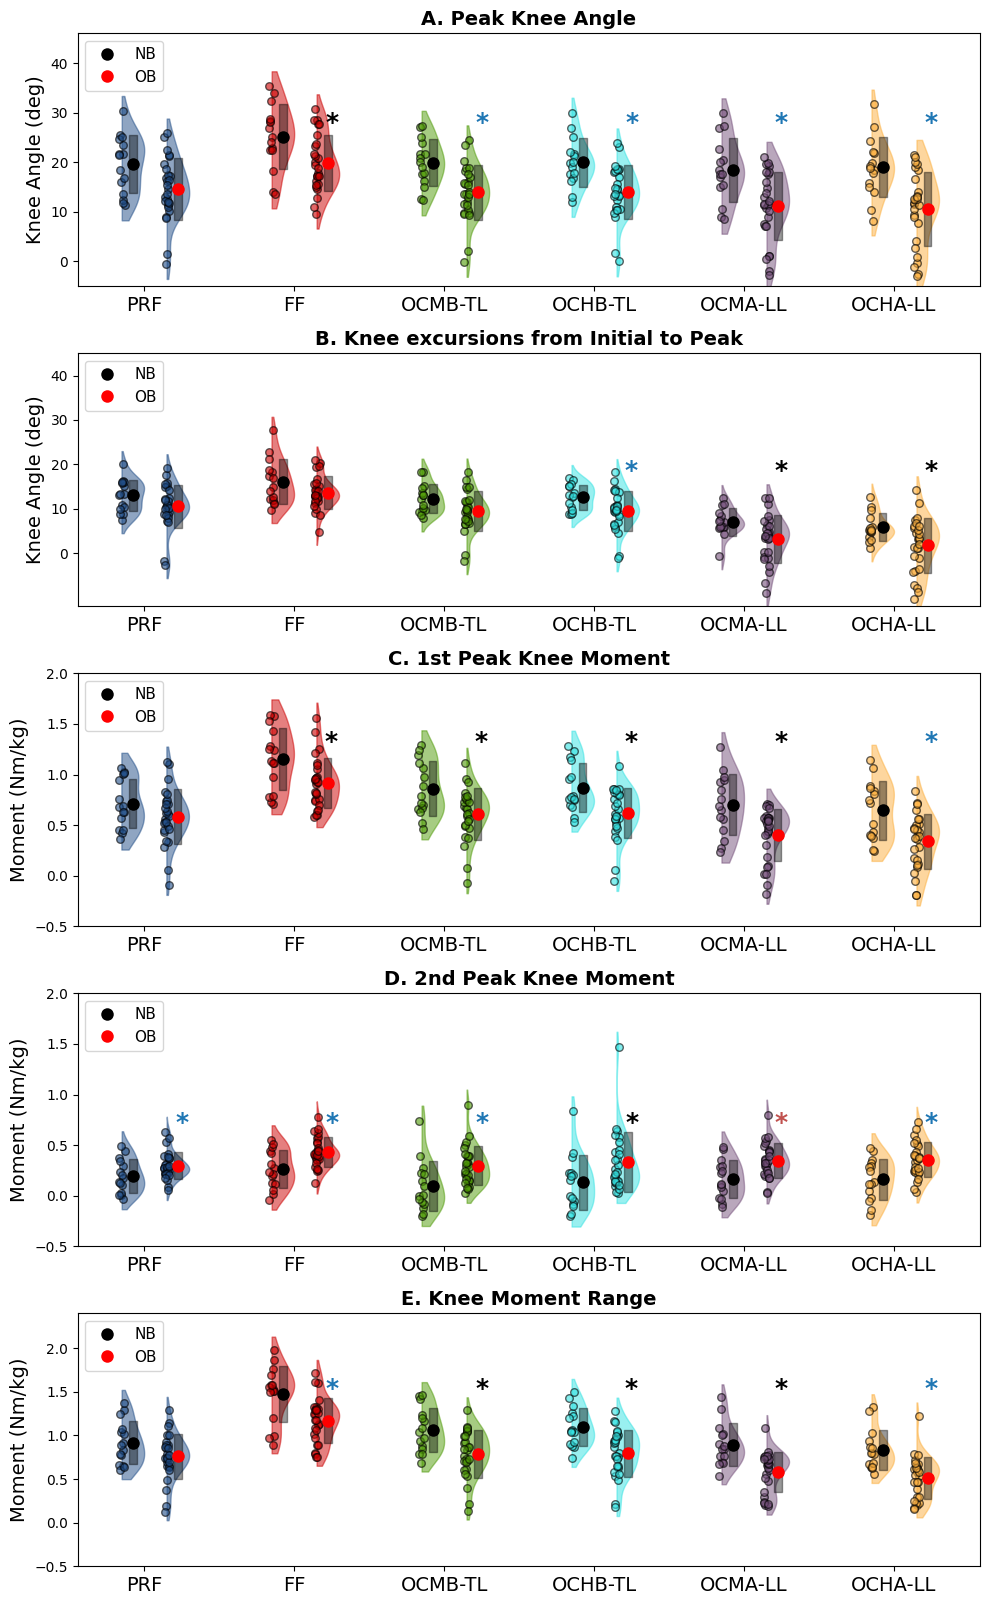

Saved: Fig.6.png


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pandas as pd
from matplotlib.lines import Line2D


# === Load CSV ===
df = pd.read_csv("per_id_task_means_group.csv")


# === Define Parameters ===
original_tasks = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]
display_tasks = ["PRF", "FF", "OCMB-TL", "OCHB-TL", "OCMA-LL", "OCHA-LL"]
task_display_map = dict(zip(original_tasks, display_tasks))

outcomes = ["Peak", "InitialPeak", "MomentPeak", "SecondPeak", "kneeMrange"]

titles = [
    "A. Peak Knee Angle",
    "B. Knee excursions from Initial to Peak",
    "C. 1st Peak Knee Moment",
    "D. 2nd Peak Knee Moment",
    "E. Knee Moment Range"
]
 
task_colors = {
    "PRF": "#204D87",
    "FF": "#CC0000",
    "OCMB": "#4E9A06",
    "OCHB": "#34E2E2",
    "OCMA": "#75507B",
    "OCHA": "#FCAF3E"
}

group_offsets = {"NB": -0.15, "OB": 0.15}
group_colors = {"NB": "black", "OB": "red"}

y_limits = {
    "Peak": (-5, 46),
    "InitialPeak": (-12, 45),
    "MomentPeak": (-0.5, 2.0),
    "SecondPeak": (-0.5, 2.0),
    "kneeMrange": (-0.5, 2.4)
}

moment_outcomes = ["MomentPeak", "SecondPeak", "kneeMrange"]


# === Create Subplots ===
fig, axes = plt.subplots(5, 1, figsize=(10, 17), sharey=False)
axes = axes.flatten()

ax0 = axes[0]  # Peak
ax1 = axes[1]  # InitialPeak
ax2 = axes[2]  # MomentPeak
ax3 = axes[3]  # SecondPeak
ax4 = axes[4]  # kneeMrange


# === Manual significance asterisks ===
def add_star(ax, task, y, color="black", fontsize=18):
    task_index = original_tasks.index(task)
    x1 = task_index + 0
    x2 = task_index + 0.2

    ax.text(
        (x1 + x2 + 0.3) / 2,
        y,
        "*",
        ha="center",
        va="bottom",
        color=color,
        fontsize=fontsize,
        fontweight="bold"
    )


# OCHA
add_star(ax0, "OCHA", 25.5, color="#1f77b4")
add_star(ax1, "OCHA", 15.7)
add_star(ax2, "OCHA", 1.2, color="#1f77b4")
add_star(ax3, "OCHA", 0.6, color="#1f77b4")
add_star(ax4, "OCHA", 1.4, color="#1f77b4")
# OCMA
add_star(ax0, "OCMA", 25.5, color="#1f77b4")
add_star(ax1, "OCMA", 15.7)
add_star(ax2, "OCMA", 1.2)
add_star(ax3, "OCMA", 0.6, color="#C1524F")
add_star(ax4, "OCMA", 1.4)
# OCHB
add_star(ax0, "OCHB", 25.5, color="#1f77b4")
add_star(ax1, "OCHB", 15.7, color="#1f77b4")
add_star(ax2, "OCHB", 1.2)
add_star(ax3, "OCHB", 0.6)
add_star(ax4, "OCHB", 1.4)
# OCMB
add_star(ax0, "OCMB", 25.5, color="#1f77b4")
add_star(ax2, "OCMB", 1.2)
add_star(ax3, "OCMB", 0.6, color="#1f77b4")
add_star(ax4, "OCMB", 1.4)
# FF
add_star(ax0, "FF", 25.5)
add_star(ax2, "FF", 1.2)
add_star(ax3, "FF", 0.6, color="#1f77b4")
add_star(ax4, "FF", 1.4, color="#1f77b4")

# PRF
add_star(ax3, "PRF", 0.6, color="#1f77b4")

# === Loop through outcomes, tasks, and groups ===
for ax, outcome, title in zip(axes, outcomes, titles):
    for i, task in enumerate(original_tasks):
        for group in ["NB", "OB"]:
            subset = df[
                (df["Task"] == task) &
                (df["Group"] == group)
            ][outcome].dropna()

            if len(subset) >= 2:
                kde = gaussian_kde(subset)

                if outcome in moment_outcomes:
                    x_vals = np.linspace(subset.min() - 0.1, subset.max() + 0.15, 200)
                    y_vals = kde(x_vals)
                    y_vals = y_vals / y_vals.max() * 0.15
                else:
                    x_vals = np.linspace(subset.min() - 3, subset.max() + 3, 200)
                    y_vals = kde(x_vals)
                    y_vals = y_vals / y_vals.max() * 0.15

                offset = group_offsets[group]
                violin_color = task_colors[task]
                mean_color = group_colors[group]
                x_pos = i + offset

                # Cloud KDE
                ax.fill_betweenx(
                    x_vals,
                    x_pos,
                    x_pos + y_vals,
                    color=violin_color,
                    alpha=0.5
                )

                # Rain dots
                jitter = np.random.uniform(-0.02, 0.02, size=len(subset))
                ax.scatter(
                    x_pos + jitter,
                    subset,
                    color=violin_color,
                    edgecolor="black",
                    alpha=0.6,
                    s=30,
                    zorder=5
                )

                # Mean and SD marker
                mean = subset.mean()
                std = subset.std()

                ax.plot(
                    x_pos + 0.075,
                    mean,
                    marker="o",
                    color=mean_color,
                    markersize=8,
                    zorder=10
                )

                ax.fill_betweenx(
                    [mean - std, mean + std],
                    x_pos + 0.05,
                    x_pos + 0.1,
                    color="black",
                    alpha=0.4
                )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(range(len(display_tasks)))
    ax.set_xticklabels(display_tasks, fontsize=14)

    if outcome in moment_outcomes:
        ax.set_ylabel("Moment (Nm/kg)", fontsize=14)
        ax.set_yticks([-0.5, 0, 0.5, 1.0, 1.5, 2.0])
    else:
        ax.set_ylabel("Knee Angle (deg)", fontsize=14)
        ax.set_yticks([ 0, 10, 20, 30, 40])

    ax.set_ylim(y_limits.get(outcome, (0, 2.0)))


# === Legend ===
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="NB",
        markerfacecolor=group_colors["NB"],
        markeredgecolor="none",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="OB",
        markerfacecolor=group_colors["OB"],
        markeredgecolor="none",
        markersize=9
    )
]

for ax in axes:
    ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True)


# === Final layout and save ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Fig.6.png", dpi=1000)
plt.show()

print("Saved: Fig.6.png")


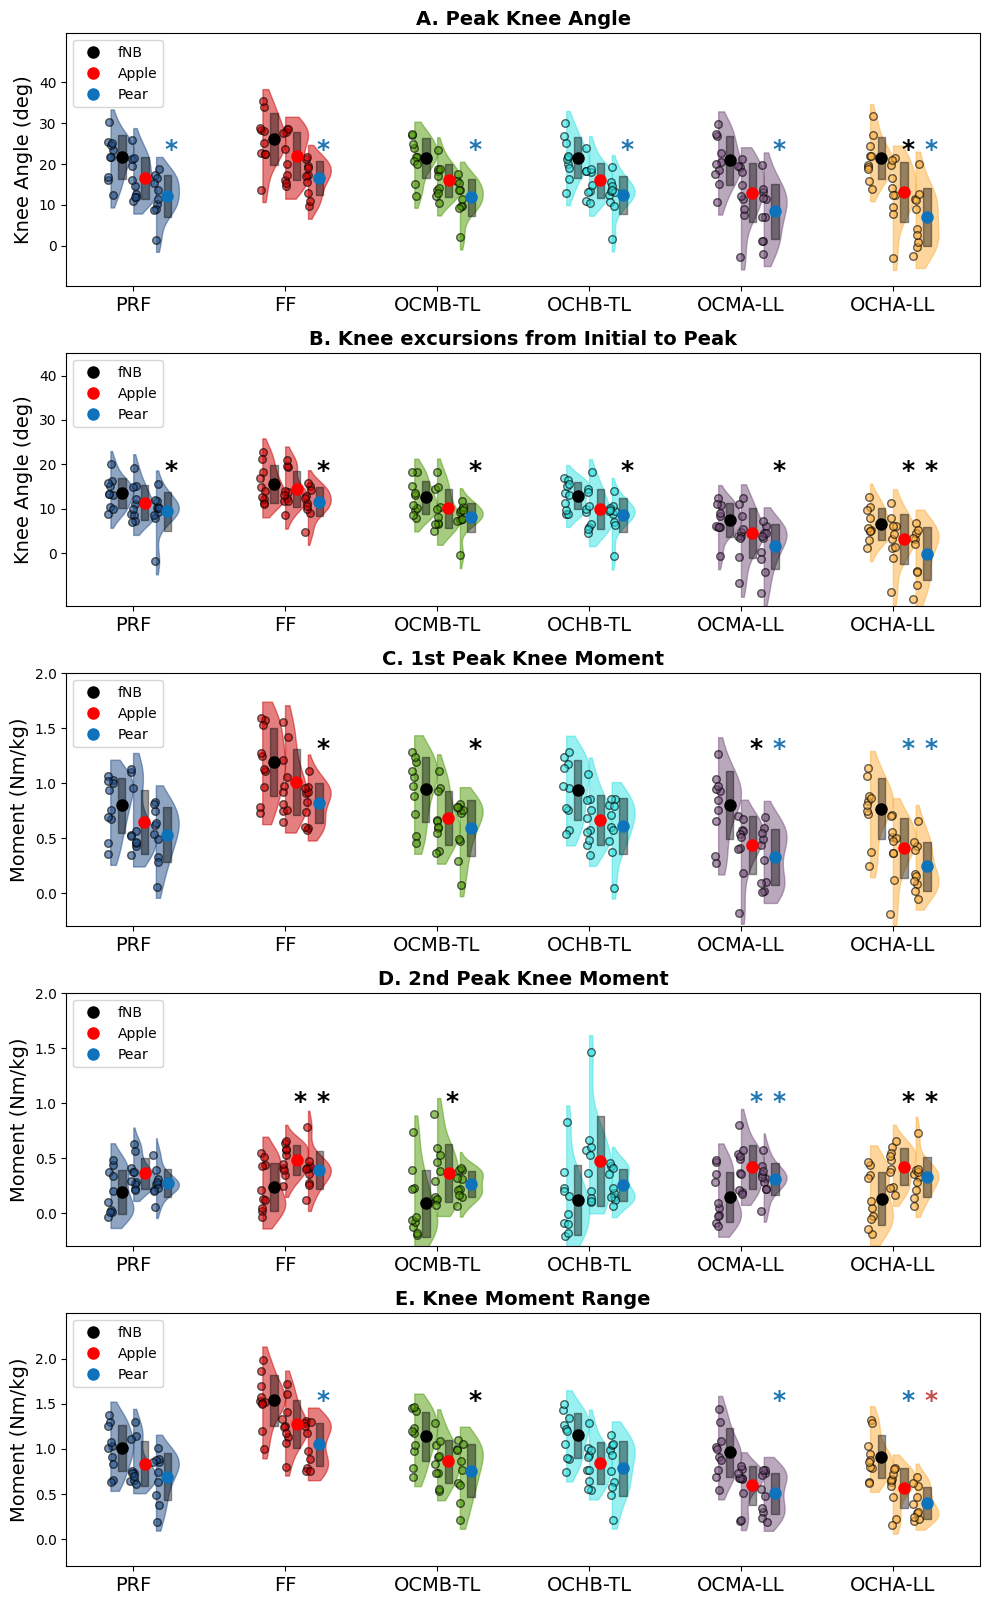

Saved: Fig.7.png


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pandas as pd
from matplotlib.lines import Line2D

# === Load CSV ===
df = pd.read_csv("per_id_task_means_female_body_shape.csv")

# === Define Parameters ===
original_tasks = ["PRF", "FF", "OCMB", "OCHB", "OCMA", "OCHA"]
display_tasks = ["PRF", "FF", "OCMB-TL", "OCHB-TL", "OCMA-LL", "OCHA-LL"]
task_display_map = dict(zip(original_tasks, display_tasks))

outcomes = ["Peak", "InitialPeak", "MomentPeak", "SecondPeak", "kneeMrange"]
titles = [
    "A. Peak Knee Angle",
    "B. Knee excursions from Initial to Peak",
    "C. 1st Peak Knee Moment",
    "D. 2nd Peak Knee Moment",
    "E. Knee Moment Range",
]

task_colors = {
    "PRF": "#204D87",
    "FF": "#CC0000",
    "OCMB": "#4E9A06",
    "OCHB": "#34E2E2",
    "OCMA": "#75507B",
    "OCHA": "#FCAF3E"
}

group_mean_colors = {
    "Normal BMI": "black",
    "Apple": "red",
    "Pear": "#0E73BA"
}

group_offsets = {"Normal BMI": -0.15, "Apple": 0.0, "Pear": 0.15}

y_limits = {
    "Peak": (-9.9, 52),
    "InitialPeak": (-12, 45),
    "MomentPeak": (-0.3, 2.0),
    "SecondPeak": (-0.3, 2.0),
    "kneeMrange": (-0.3, 2.5)
}

moment_outcomes = ["MomentPeak", "SecondPeak", "kneeMrange"]

# === Create Subplots ===
fig, axes = plt.subplots(5, 1, figsize=(10, 17), sharey=False)
axes = axes.flatten()

ax0 = axes[0]  # Peak
ax1 = axes[1]  # InitialPeak
ax2 = axes[2]  # MomentPeak
ax3 = axes[3]  # SecondPeak
ax4 = axes[4]  # kneeMrange

# === Manual significance asterisks ===
def add_star(ax, task, y, color="black", fontsize=18, shift=0.3):
    task_index = original_tasks.index(task)
    x1 = task_index + 0
    x2 = task_index + 0.2
    ax.text(
        (x1 + x2 + shift) / 2,
        y,
        "*",
        ha="center",
        va="bottom",
        color=color,
        fontsize=fontsize,
        fontweight="bold"
    )

# OCHA
add_star(ax0, "OCHA", 20.5, shift=0.0)
add_star(ax0, "OCHA", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "OCHA", 15.7, shift=0.0)
add_star(ax1, "OCHA", 15.7, shift=0.3)
add_star(ax2, "OCHA", 1.2, color="#1f77b4", shift=0.0)
add_star(ax2, "OCHA", 1.2, color="#1f77b4", shift=0.3)
add_star(ax3, "OCHA", 0.9, shift=0.3)
add_star(ax3, "OCHA", 0.9, shift=0.0)
add_star(ax4, "OCHA", 1.4, color="#1f77b4", shift=0.0)
add_star(ax4, "OCHA", 1.4, color="#C1524F", shift=0.3)

# OCMA
add_star(ax0, "OCMA", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "OCMA", 15.7, shift=0.3)
add_star(ax2, "OCMA", 1.2, shift=0.0)
add_star(ax2, "OCMA", 1.2, color="#1f77b4", shift=0.3)
add_star(ax3, "OCMA", 0.9, color="#1f77b4", shift=0.3)
add_star(ax3, "OCMA", 0.9, color="#1f77b4", shift=0)
add_star(ax4, "OCMA", 1.4, color="#1f77b4", shift=0.3)

# OCHB
add_star(ax0, "OCHB", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "OCHB", 15.7, shift=0.3)


# OCMB
add_star(ax0, "OCMB", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "OCMB", 15.7, shift=0.3)
add_star(ax2, "OCMB", 1.2, shift=0.3)
add_star(ax3, "OCMB", 0.9, shift=0.0)
add_star(ax4, "OCMB", 1.4, shift=0.3)

# FF
add_star(ax0, "FF", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "FF", 15.7, shift=0.3)
add_star(ax2, "FF", 1.2, shift=0.3)
add_star(ax3, "FF", 0.9, shift=0.3)
add_star(ax3, "FF", 0.9, shift=0.0)
add_star(ax4, "FF", 1.4, color="#1f77b4", shift=0.3)

# PRF
add_star(ax0, "PRF", 20.5, color="#1f77b4", shift=0.3)
add_star(ax1, "PRF", 15.7, color="black", shift=0.3)

# === Loop through outcomes, tasks, and groups ===
for ax, outcome, title in zip(axes, outcomes, titles):
    for i, task in enumerate(original_tasks):
        for group in ["Normal BMI", "Apple", "Pear"]:
            subset = df[
                (df["Task"] == task) &
                (df["Body Shape"] == group)
            ][outcome].dropna()

            if len(subset) >= 2:
                kde = gaussian_kde(subset)

                if outcome in moment_outcomes:
                    x_vals = np.linspace(subset.min() - 0.1, subset.max() + 0.15, 200)
                    y_vals = kde(x_vals)
                    y_vals = y_vals / y_vals.max() * 0.15
                else:
                    x_vals = np.linspace(subset.min() - 3, subset.max() + 3, 200)
                    y_vals = kde(x_vals)
                    y_vals = y_vals / y_vals.max() * 0.15

                offset = group_offsets[group]
                violin_color = task_colors[task]
                mean_color = group_mean_colors[group]
                x_pos = i + offset

                ax.fill_betweenx(
                    x_vals, x_pos, x_pos + y_vals,
                    color=violin_color, alpha=0.5
                )

                jitter = np.random.uniform(-0.02, 0.02, size=len(subset))
                ax.scatter(
                    x_pos + jitter, subset,
                    color=violin_color,
                    edgecolor="black",
                    alpha=0.6,
                    s=30,
                    zorder=5
                )

                mean = subset.mean()
                std = subset.std()
                ax.plot(
                    x_pos + 0.075, mean,
                    marker="o",
                    color=mean_color,
                    markersize=8,
                    zorder=10
                )
                ax.fill_betweenx(
                    [mean - std, mean + std],
                    x_pos + 0.05, x_pos + 0.1,
                    color="black",
                    alpha=0.4
                )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(range(len(display_tasks)))
    ax.set_xticklabels(display_tasks, fontsize=14)

    if outcome in moment_outcomes:
        ax.set_ylabel("Moment (Nm/kg)", fontsize=14)
        ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
    else:
        ax.set_ylabel("Knee Angle (deg)", fontsize=14)
        ax.set_yticks([0, 10, 20, 30, 40])

    ax.set_ylim(y_limits.get(outcome, (0, 2.0)))

# === Legend ===
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="fNB",
           markerfacecolor=group_mean_colors["Normal BMI"], markeredgecolor="none", markersize=9),
    Line2D([0], [0], marker="o", color="w", label="Apple",
           markerfacecolor=group_mean_colors["Apple"], markeredgecolor="none", markersize=9),
    Line2D([0], [0], marker="o", color="w", label="Pear",
           markerfacecolor=group_mean_colors["Pear"], markeredgecolor="none", markersize=9)
]

for ax in axes:
    ax.legend(handles=legend_elements, loc="upper left", fontsize=10, frameon=True)

# === Final layout and save ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Fig.7.png", dpi=1000)
plt.show()

print("Saved: Fig.7.png")


Sample sizes by body type
---------------------------------------------
NB: OCHA n = 10, OCMA n = 10
Apple: OCHA n = 10, OCMA n = 10
Pear: OCHA n = 10, OCMA n = 10
---------------------------------------------


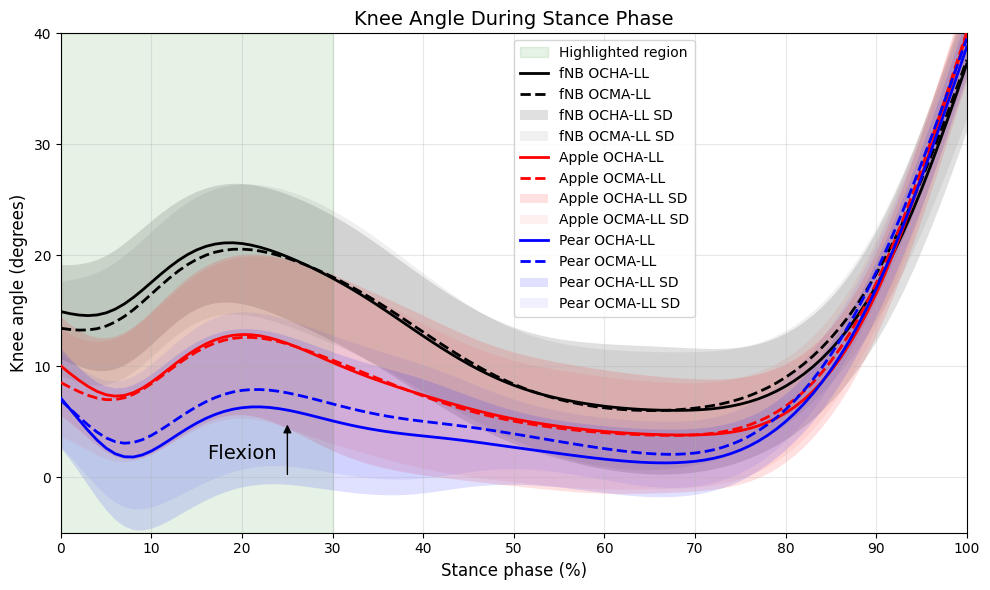

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. File names
# --------------------------------------------------

OCHA_FILE = "Anova_OCHA.csv"
OCMA_FILE = "Anova_OCMA.csv"


# --------------------------------------------------
# 2. Figure settings
# --------------------------------------------------
FIG_SIZE = (10, 6)

TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 10

LINE_WIDTH = 2.0

SHOW_SD = True
SHOW_HIGHLIGHT = True
SHOW_GRID = True

SD_ALPHA_OCHA = 0.12
SD_ALPHA_OCMA = 0.06


# --------------------------------------------------
# 3. Group and line settings

GROUP_MAP = {
    1: "NB",
    2: "Apple",
    3: "Pear",
}

# 체형별 색상
GROUP_COLORS = {
    "NB": "black",
    "Apple": "red",
    "Pear": "blue",
}

# 조건별 선 모양
CONDITION_STYLES = {
    "OCHA": "-",    
    "OCMA": "--",   
}


# --------------------------------------------------
# 4. Load and validate data
# --------------------------------------------------
def load_waveform_data(csv_file):
  
    data = pd.read_csv(csv_file)

    required_columns = {"Group", "Speed"}

    missing_columns = required_columns.difference(
        data.columns
    )

    if missing_columns:
        raise ValueError(
            f"{csv_file}: missing required columns "
            f"{sorted(missing_columns)}"
        )

    waveform_columns = [
        str(i) for i in range(101)
    ]

    missing_waveform_columns = [
        column
        for column in waveform_columns
        if column not in data.columns
    ]

    if missing_waveform_columns:
        raise ValueError(
            f"{csv_file}: missing waveform columns "
            f"{missing_waveform_columns}"
        )

    data[waveform_columns] = (
        data[waveform_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    data["Group"] = pd.to_numeric(
        data["Group"],
        errors="coerce",
    )

    data["Speed"] = pd.to_numeric(
        data["Speed"],
        errors="coerce",
    )

    if data[waveform_columns].isna().any().any():
        raise ValueError(
            f"{csv_file}: waveform data contain "
            "missing or nonnumeric values."
        )

    if data["Group"].isna().any():
        raise ValueError(
            f"{csv_file}: Group contains missing "
            "or nonnumeric values."
        )

    data["Group"] = data["Group"].astype(int)

    # 정의되지 않은 Group 코드 확인
    unknown_groups = sorted(
        set(data["Group"]).difference(GROUP_MAP)
    )

    if unknown_groups:
        raise ValueError(
            f"{csv_file}: unknown Group codes "
            f"{unknown_groups}"
        )

    return data, waveform_columns


# OCHA와 OCMA 데이터 불러오기
OCHA_data, OCHA_columns = load_waveform_data(
    OCHA_FILE
)

OCMA_data, OCMA_columns = load_waveform_data(
    OCMA_FILE
)

# 두 파일의 파형 열이 동일한지 확인
if OCHA_columns != OCMA_columns:
    raise ValueError(
        "OCHA and OCMA waveform columns do not match."
    )

# Stance phase: 0~100%
stance_phase = np.arange(101)


# --------------------------------------------------
# 5. Calculate mean and SD
# --------------------------------------------------
def calculate_group_statistics(
    data,
    waveform_columns,
    group_code,
):
  
    group_data = data.loc[
        data["Group"] == group_code,
        waveform_columns,
    ]

    if group_data.empty:
        raise ValueError(
            f"No data found for Group {group_code}."
        )

    values = group_data.to_numpy(dtype=float)

    mean_curve = np.mean(
        values,
        axis=0,
    )

    if values.shape[0] > 1:
        sd_curve = np.std(
            values,
            axis=0,
            ddof=1,
        )
    else:
        sd_curve = np.zeros(
            values.shape[1],
            dtype=float,
        )

    return mean_curve, sd_curve, values.shape[0]


group_statistics = {}

for group_code, group_name in GROUP_MAP.items():
    OCHA_mean, OCHA_sd, OCHA_n = (
        calculate_group_statistics(
            OCHA_data,
            OCHA_columns,
            group_code,
        )
    )

    OCMA_mean, OCMA_sd, OCMA_n = (
        calculate_group_statistics(
            OCMA_data,
            OCMA_columns,
            group_code,
        )
    )

    group_statistics[group_name] = {
        "OCHA_mean": OCHA_mean,
        "OCHA_sd": OCHA_sd,
        "OCHA_n": OCHA_n,
        "OCMA_mean": OCMA_mean,
        "OCMA_sd": OCMA_sd,
        "OCMA_n": OCMA_n,
    }


# --------------------------------------------------
# 6. Print sample sizes
# --------------------------------------------------
print("\nSample sizes by body type")
print("-" * 45)

for group_name, stats in group_statistics.items():
    print(
        f"{group_name}: "
        f"OCHA n = {stats['OCHA_n']}, "
        f"OCMA n = {stats['OCMA_n']}"
    )

print("-" * 45)


# --------------------------------------------------
# 7. Plot setup
# --------------------------------------------------
fig, ax = plt.subplots(
    figsize=FIG_SIZE
)


# --------------------------------------------------
# 8. Highlight early stance
# --------------------------------------------------
if SHOW_HIGHLIGHT:
    ax.axvspan(
        0,
        30,
        color="green",
        alpha=0.10,
        label="Highlighted region",
        zorder=0,
    )


# --------------------------------------------------
# 9. Plot body-type curves
# --------------------------------------------------

LEGEND_NAME_MAP = {
    "NB": "fNB",
    "Apple": "Apple",
    "Pear": "Pear",
    "OCHA-LL": "OCHA-LL",
    "OCMA-LL": "OCMA-LL",
}
for group_name in ["NB", "Apple", "Pear"]:
    color = GROUP_COLORS[group_name]
    stats = group_statistics[group_name]

 
    ax.plot(
        stance_phase,
        stats["OCHA_mean"],
        color=color,
        linestyle=CONDITION_STYLES["OCHA"],
        linewidth=LINE_WIDTH,
        label=f"{LEGEND_NAME_MAP[group_name]} {LEGEND_NAME_MAP['OCHA-LL']}",
        zorder=3,
    )

    ax.plot(
        stance_phase,
        stats["OCMA_mean"],
        color=color,
        linestyle=CONDITION_STYLES["OCMA"],
        linewidth=LINE_WIDTH,
        label=f"{LEGEND_NAME_MAP[group_name]} {LEGEND_NAME_MAP['OCMA-LL']}",
        zorder=3,
    )

    if SHOW_SD:
      
        ax.fill_between(
            stance_phase,
            stats["OCHA_mean"] - stats["OCHA_sd"],
            stats["OCHA_mean"] + stats["OCHA_sd"],
            color=color,
            alpha=SD_ALPHA_OCHA,
            linewidth=0,
            label=f"{LEGEND_NAME_MAP[group_name]} OCHA-LL SD",
            zorder=1,
        )

        ax.fill_between(
            stance_phase,
            stats["OCMA_mean"] - stats["OCMA_sd"],
            stats["OCMA_mean"] + stats["OCMA_sd"],
            color=color,
            alpha=SD_ALPHA_OCMA,
            linewidth=0,
            label=f"{LEGEND_NAME_MAP[group_name]} OCMA-LL SD",
            zorder=1,
        )


# --------------------------------------------------
# 10. Axes settings
# --------------------------------------------------
ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 10)
)


ax.set_ylim(-5, 40)

ax.set_yticks(
    [0, 10, 20, 30, 40]
)

ax.set_xlabel(
    "Stance phase (%)",
    fontsize=LABEL_FONTSIZE,
)

ax.set_ylabel(
    "Knee angle (degrees)",
    fontsize=LABEL_FONTSIZE,
)

ax.set_title(
    "Knee Angle During Stance Phase",
    fontsize=TITLE_FONTSIZE,
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FONTSIZE,
)


# --------------------------------------------------
# 11. Grid
# --------------------------------------------------
if SHOW_GRID:
    ax.grid(
        alpha=0.3
    )


# --------------------------------------------------
# 12. Flexion annotation
# --------------------------------------------------
ax.text(
    20,
    3,
    "Flexion",
    fontsize=14,
    verticalalignment="top",
    horizontalalignment="center",
)

ax.annotate(
    "",
    xy=(25, 5),
    xytext=(25, 0),
    arrowprops={
        "arrowstyle": "-|>",
        "color": "black",
        "linewidth": 1.0,
        "mutation_scale": 12,
    },
)


# --------------------------------------------------
# 13. Legend
# --------------------------------------------------

ax.legend(
    fontsize=LEGEND_FONTSIZE,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.0),
    frameon=True,
    ncol=1,
)


# --------------------------------------------------
# 14. Save and display
# --------------------------------------------------
plt.tight_layout()

plt.savefig(
    "Fig.S2.png",
    dpi=1000,
    bbox_inches="tight",
)

plt.show()